# Weiss et al, 2026: Single-cell spatial proteomics on human liver zonation

This notebook demonstrates a complete proteomics analysis workflow using **alphapepttools**, reproducing and extending the analysis from the scDVP (single-cell Deep Visual Proteomics) study of human liver zonation: https://www.nature.com/articles/s42255-026-01459-2

## 1. Study Background

In liver lobules, hepatocytes perform distinct metabolic functions depending on their spatial position along the axis from the portal vein to the central vein, a phenomenon known as liver zonation. In the [study by Weiss and colleagues](https://www.nature.com/articles/s42255-026-01459-2), single hepatocytes were isolated along this porto-central axis using laser microdissection, followed by mass-spectrometry–based single-cell proteomics. By preserving information about each cell’s spatial origin within the intact tissue, the authors were able to reconstruct spatial trajectories for thousands of proteins and quantify how protein expression patterns change across zonation in both healthy and pathological states.

Single-cell proteomics is a low-input application of mass spectrometry, which introduces several analytical challenges, including a high proportion of missing values, missingness that is not random, and increased susceptibility to technical noise. In this tutorial, we will use this dataset to demonstrate practical strategies for exploring, processing, and interpreting scDVP proteomics data.

---

## 2. Learning Objectives

1. **Data Loading & Preprocessing**: Import proteomics data into the AnnData format
2. **Quality Control**: Assess sample and protein quality, identify batch effects if any exist
3. **Filtering**: Apply informed thresholds based on QC metrics
4. **Dimensionality Reduction**: Use PCA to explore variance structure
5. **Biological Interpretation**: Recreate zonation heatmaps and infer transcription factor activity
6. **Spatial Integration**: Overlay proteomics data with the original tissue image using SpatialData

---

## 3. Key Proteomics Considerations

| Challenge | Why It Matters | Our Approach |
|-----------|---------------|--------------|
| **Missing values** | Proteomics data is ~20-50% missing (MNAR) | Flag, don't impute blindly |
| **Dynamic range** | Proteins span 6+ orders of magnitude | Log-transform intensities |
| **Batch effects** | Donor/plate effects can dominate | QC visualization, consider correction |
| **Low protein counts** | Single-cell = fewer IDs than bulk | Filter carefully |

---

## 4. References

  - **scDVP Study**: Weiss, C.A.M., et al. (2026). Single-cell spatial proteomics maps human liver zonation patterns and their vulnerability to disruption in tissue architecture. Nature Metabolism. https://www.nature.com/articles/s42255-026-01459-2

  - **DirectLFQ**: Ammar, C., et al. (2023). Accurate label-free quantification by directLFQ to compare unlimited numbers of proteomes. Molecular & Cellular Proteomics, 22(7). https://doi.org/10.1016/j.mcpro.2023.100581

  - **DIANN**: Demichev, Vadim, et al. "DIA-NN: neural networks and interference correction enable deep proteome coverage in high throughput." Nature Methods 17.1 (2020): 41-44.

  - **Scanpy**: Wolf, F.A., Angerer, P., & Theis, F.J. (2018). SCANPY: large-scale single-cell gene expression data analysis. Genome Biology, 19(1), 15. https://doi.org/10.1186/s13059-017-1382-0

  - **Single-cell Best Practices (RNA-seq)**: Luecken, M.D., & Theis, F.J. (2019). Current best practices in single-cell RNA-seq analysis: a tutorial. Molecular Systems Biology, 15(6), e8746. https://doi.org/10.15252/msb.20188746

  - **Single-cell Best Practices (Multi-modal)**: Heumos, L., et al. (2023). Best practices for single-cell analysis across modalities. Nature Reviews Genetics, 24(8), 550-572. https://doi.org/10.1038/s41576-023-00586-w

  - **Decoupler**: Badia-i-Mompel, P., et al. (2022). decoupleR: ensemble of computational methods to infer biological activities from omics data. Bioinformatics Advances, 2(1), vbac016. https://doi.org/10.1093/bioadv/vbac016

  - **SpatialData**: Marconato, L., Palla, G., Yamauchi, K.A. et al. SpatialData: an open and universal data framework for spatial omics. Nat Methods 22, 58–62 (2025). https://doi.org/10.1038/s41592-024-02212-x

In [3]:
%load_ext autoreload
%autoreload 2

import alphapepttools as apt
import matplotlib.pyplot as plt
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import warnings
import tempfile
import os

### Special figure imports
from alphapepttools.pl.colors import MappedColormaps
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from matplotlib.transforms import Bbox
import cmcrameri.cm as cmc

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

## 5. Data Loading
We load the dataset used for the study which contains 769 heptocytes taken from 18 donors, with a total of 5175 identified protein groups. 
The data were analyzed with DIA-NN and resulted report file was normalized using directLFQ.

In [4]:
output_dir = "./datasets/data_for_study_04_scDVP_Hep_workflow"
figure_output_dir = "../../assets/figures_for_study_04_scDVP_Hep_workflow"

pg_table_path = apt.data.get_data("Weiss2026_pg_directLFQ", output_dir=output_dir if output_dir else tempfile.mkdtemp())
obs_metadata_path = apt.data.get_data("Weiss2026_metadata", output_dir=output_dir if output_dir else tempfile.mkdtemp())
var_metadata_path = apt.data.get_data(
    "Uniprot_to_GeneSymbol_file", output_dir=output_dir if output_dir else tempfile.mkdtemp()
)

adata = apt.io.read_pg_table(pg_table_path, search_engine="directlfq")
obs_metadata = pd.read_csv(obs_metadata_path, sep=",", index_col=0)
var_metadata = pd.read_csv(var_metadata_path, sep=",", index_col=0)


# print adata and metadata to verify successful loading
display(adata.to_df().head())
display(obs_metadata.head())
display(var_metadata.head())

./datasets/data_for_study_04_scDVP_Hep_workflow/scDVP.report.tsv.protein_intensities.tsv already exists (37.4078893661499 MB)
./datasets/data_for_study_04_scDVP_Hep_workflow/metadata_scDVP.csv already exists (0.09111309051513672 MB)
./datasets/data_for_study_04_scDVP_Hep_workflow/Uniprot_to_GeneSymbol.csv already exists (0.15979480743408203 MB)


uniprot_ids,A0A024R1R8;Q9Y2S6,A0A075B6H7;A0A0C4DH55;P01624,A0A075B6I0,A0A075B6K4,A0A075B6K5,A0A075B6P5;P01615,A0A075B6R9;A0A0C4DH68,A0A087WSY6,A0A0A0MRZ8;P04433,A0A0A0MS15,...,Q9Y6N8,Q9Y6Q5,Q9Y6R1,Q9Y6R7,Q9Y6U3,Q9Y6V7,Q9Y6W3,Q9Y6X4,Q9Y6Y8,Q9Y6Z7
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_01,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,9662.634298,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_02,0.000000,13032.087818,0.0,0.0,0.000000,0.000000,0.0,0.0,13694.136179,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_03,0.000000,16351.507957,0.0,0.0,0.000000,6400.357454,0.0,0.0,10409.959084,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,4860.785945,0.0
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_04,21068.309869,21729.115322,0.0,0.0,2352.444061,5735.512100,0.0,0.0,10518.617833,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12174.755055,7423.415566,0.0
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_05,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0


,id,score,donor_id,plate_id,condition,geometry_id
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_01,92.0,0.172537,CHTL36,plate_2,desmoplasia,1
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_02,95.0,0.289923,CHTL36,plate_2,desmoplasia,2
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_03,99.0,0.389010,CHTL36,plate_2,desmoplasia,3
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_04,104.0,0.534056,CHTL36,plate_2,desmoplasia,4
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_05,109.0,0.632710,CHTL36,plate_2,desmoplasia,5


,Protein.Group,Protein.Names,Genes
protein,,,
A0A024R1R8;Q9Y2S6,A0A024R1R8;Q9Y2S6,TMA7B_HUMAN;TMA7_HUMAN,TMA7;TMA7B
A0A075B6H7;A0A0C4DH55;P01624,A0A075B6H7;A0A0C4DH55;P01624,KV315_HUMAN;KV37_HUMAN;KVD07_HUMAN,IGKV3-15;IGKV3-7;IGKV3D-7
A0A075B6I0,A0A075B6I0,LV861_HUMAN,IGLV8-61
A0A075B6K4,A0A075B6K4,LV310_HUMAN,IGLV3-10
A0A075B6K5,A0A075B6K5,LV39_HUMAN,IGLV3-9


### 5.1 **Joining metadata to quantitative data**

Next, we join the metadata for the `obs` and `var` to have the complete dataset in the anndata.

In [5]:
# add the metadata to the AnnData object
adata = apt.pp.add_metadata(
    adata=adata,
    incoming_metadata=obs_metadata,
    axis=0,  # 0 for obs (samples), 1 for var (features)
    keep_data_shape=False,  # drops unmatched samples
)

adata.var = adata.var.merge(var_metadata, left_index=True, right_index=True, how="left")

display(adata.obs.head())
display(adata.var.head())

,id,score,donor_id,plate_id,condition,geometry_id
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_01,92.0,0.172537,CHTL36,plate_2,desmoplasia,1
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_02,95.0,0.289923,CHTL36,plate_2,desmoplasia,2
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_03,99.0,0.389010,CHTL36,plate_2,desmoplasia,3
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_04,104.0,0.534056,CHTL36,plate_2,desmoplasia,4
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_05,109.0,0.632710,CHTL36,plate_2,desmoplasia,5


,Protein.Group,Protein.Names,Genes
uniprot_ids,,,
A0A024R1R8;Q9Y2S6,A0A024R1R8;Q9Y2S6,TMA7B_HUMAN;TMA7_HUMAN,TMA7;TMA7B
A0A075B6H7;A0A0C4DH55;P01624,A0A075B6H7;A0A0C4DH55;P01624,KV315_HUMAN;KV37_HUMAN;KVD07_HUMAN,IGKV3-15;IGKV3-7;IGKV3D-7
A0A075B6I0,A0A075B6I0,LV861_HUMAN,IGLV8-61
A0A075B6K4,A0A075B6K4,LV310_HUMAN,IGLV3-10
A0A075B6K5,A0A075B6K5,LV39_HUMAN,IGLV3-9


### **5.2 Data cleaning**

Since the dataset is a directLFQ output, missing values are assigned to zeroes. We replace zeroes with NaNs, as zeroes would skew data distributions. 
`detect_special_values` is a blanket function that detects problematic values like inf, -inf, 0 as well as negative values - all of which we would not expect in a proteomics dataset.

In [6]:
zero_mask = apt.pp.detect_special_values(adata.X)
adata.X = np.where(zero_mask, np.nan, adata.X)

---


## 6. Metadata Preparation: Defining Biological and Technical Covariates

The metadata contains:

`id` - the cells' identifiction  

`score` - spatial ratio of the distances to the nearest central vein and portal node. Scaled from 0 (pericentral) to 1 (periportal).

`donor_id` - unique patient identifier (18 donors)

`plate_id` - sample processing plate identifier (important for assessing batch effects)

`condition` - hepatocytes were sampled from either healthy donors (`control`) or patient with tumor-induced fibrosis (`desmoplasia`)


In [7]:
# Inspecting the individual values
print(f"There are {len(adata.obs['id'].unique())} cells in the dataset")

print(
    f"'score' ranges from {adata.obs['score'].min():.2f} to {adata.obs['score'].max():.2f}, with a mean of {adata.obs['score'].mean():.2f}"
)

print("Showing donor id counts:")
display(pd.DataFrame(adata.obs["donor_id"].value_counts()).T)

print("Showing plate id counts:")
display(pd.DataFrame(adata.obs["plate_id"].value_counts()).T)

print("Showing condition counts:")
display(pd.DataFrame(adata.obs["condition"].value_counts()).T)

There are 690 cells in the dataset
'score' ranges from 0.02 to 0.98, with a mean of 0.50
Showing donor id counts:


donor_id,CHTL36,CHTL38,NML5,NML31,CHTL73,NML17,NML16,CHTL59,NML10,NML7,CHTL3,NML6,NML15,NML11,NML4,NML20,CHTL34,NML9
count,44,44,44,44,44,44,44,44,44,44,44,43,42,42,42,41,39,36


Showing plate id counts:


plate_id,plate_5,plate_2,plate_1,plate_6,plate_4,plate_3
count,132,131,130,129,128,119


Showing condition counts:


condition,control,desmoplasia
count,598,171


### **6.1 Binning score into five zones**

We bin the score data into 5 zones to have categorical values for the spatial location.

In [8]:
# bin scores to 1 (portal most) - 5 (central most) zones for categorical analysis
adata.obs["zone"] = pd.cut(adata.obs["score"], bins=5, labels=False) + 1

# add the word "zone" before the number for clarity
adata.obs["zone"] = "zone_" + adata.obs["zone"].astype(str)
adata.obs["zone"] = adata.obs["zone"].astype("category")

display(pd.DataFrame(adata.obs["zone"].value_counts()).T)

zone,zone_3,zone_4,zone_2,zone_1,zone_5
count,221,186,174,97,91


### **6.2 Defining biological and technical variables**

The data QC will focus on identifying potential batch effects or confounding effects which might mask the biological effects. Ideally, the driver of variability in the data is the biological covariate and not the technical one. 
To assess that, we define our technical and biological variables. 

In [9]:
technical = "plate_id"  # Technical covariate (batch, donor, plate, etc.)
biological = "zone"  # Biological covariate of interest

In [10]:
# first, convert relevant columns to categorical data types
categorical_columns = ["plate_id", "donor_id", "condition", "zone"]
for col in categorical_columns:
    adata.obs[col] = adata.obs[col].astype("category")

print("Showing zone counts")
display(pd.DataFrame(adata.obs["zone"].value_counts()).T)

Showing zone counts


zone,zone_3,zone_4,zone_2,zone_1,zone_5
count,221,186,174,97,91


---


## 7. Quality Control metrics

### Why QC matters in single-cell\low input proteomics

Single-cell proteomics faces unique challenges compared to bulk:
- **Lower protein identification**
- **Higher missingness** due to sensitivity limits
- **Technical variation** due to the low input amounts, such that the signal to noise ratio can be lower.

We assess quality at two levels:

### Sample-Level Metrics
| Metric | What It Measures | 
|--------|-----------------|
| # Proteins detected | Sample complexity |
| Sum intensity | Total protein signal | 
| Missing fraction | Data completeness | 


### Protein-Level Metrics
| Metric | What It Measures |
|--------|-----------------|
| Detection frequency | How often detected |
| CV (Coefficient of Variation) | Reproducibility (Expected: biological replicates = low CV)| 
| Intensity vs missingness | MNAR pattern (Expected: low intensity = more missing) |

### **Important considerations:**

  - **Inherent sample differences**: Different samples can have legitimately different protein numbers - for example, different cell types or tissues may express different numbers of proteins. Low counts aren't always bad if biologically expected.

  - **Correlation between metrics**: There is generally a **positive correlation** between the number of detected proteins and sum intensity - samples with more signal tend to identify more proteins.

  - **Effect of normalization**: Normalization methods like **directLFQ** can decouple this relationship. After directLFQ normalization, samples may have similar sum intensities but different protein counts, which is expected behavior.

In [11]:
# Calculate sample-level QC metrics and protein level QC metrics

apt.metrics.calculate_qc_metrics(adata)
adata.obs["log10_sum_intensity"] = np.log10(adata.obs["total_sample_intensity"] + 1)

# we can check which metrics were added to the adata object
print(adata.obs.columns)
print(adata.var.columns)

Index(['id', 'score', 'donor_id', 'plate_id', 'condition', 'geometry_id',
       'zone', 'total_sample_intensity', 'num_features_detected',
       'fraction_detected_features', 'log10_sum_intensity'],
      dtype='object')
Index(['Protein.Group', 'Protein.Names', 'Genes', 'total_feature_intensity',
       'num_samples_detected', 'fraction_detected_samples'],
      dtype='object')


### **7.1 Visualizing QC Metrics by Covariate**

**Violin plots** are ideal for comparing distributions across groups. We examine QC metrics grouped by both:
1. **Technical covariate (Plate)**: Differences here indicate batch effects
2. **Biological covariate (Zone)**: Differences here may be real biology OR confounding

### What to Look For:

**Good scenario:**
- Similar distributions across technical batches → minimal batch effects
- Similar distributions of technical metrics across biological groups → no confounding effects. 
BUT, there may be cases where different biological groups have different protein amounts.

**Problematic scenario:**
- Large differences across technical batches → batch effects that need correction
- Large differences in quality of biological groups → potential confounding

In [12]:
# Enforce consistent colors for each group, in order to have the same colors across different plots and analyses
technical_color_dict = apt.pl.get_color_mapping(adata.obs[technical].unique(), apt.pl.BasePalettes.get("qualitative"))
biological_color_dict = apt.pl.get_color_mapping(
    adata.obs[biological].unique(), apt.pl.BasePalettes.get("qualitative_spectral")
)

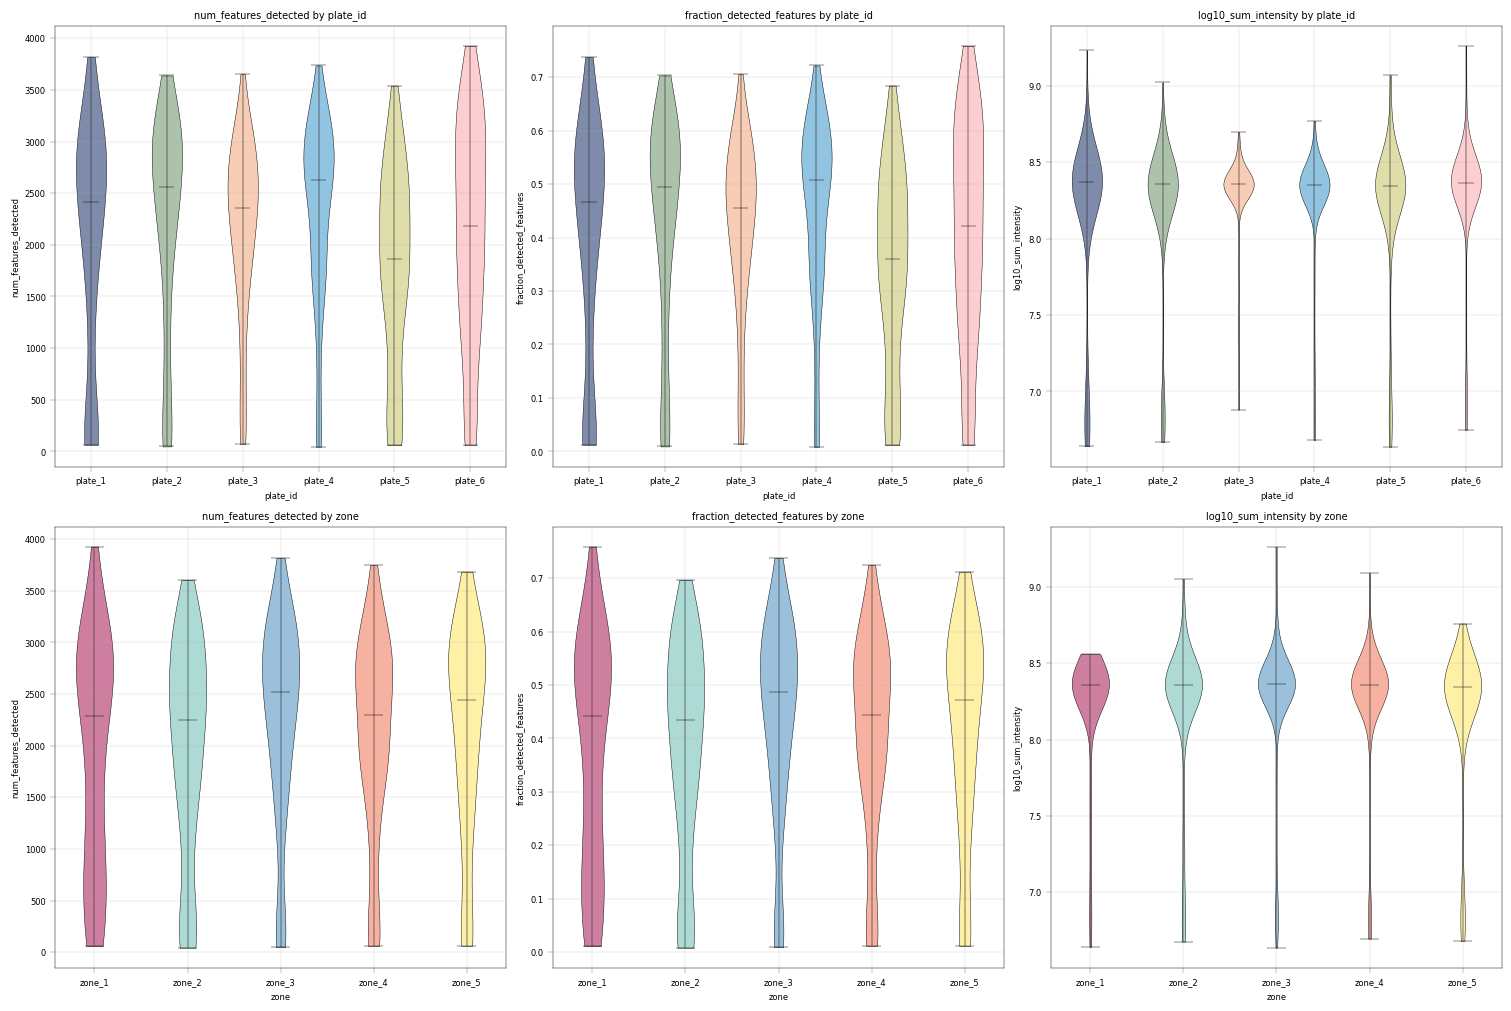

In [13]:
# Set up figure with subplots: one row per covariate, one column per QC metric
fig, axm = apt.pl.create_figure(2, 3, figsize=(15, 10))

# one row of violinplots
for covariate in [technical, biological]:
    # Order the anndata rows by the technical covariate (alphabetically)
    plate_order = adata.obs[covariate].argsort()
    adata = adata[plate_order, :]

    # decide on color dict
    color_dict = technical_color_dict if covariate == technical else biological_color_dict

    for val in ["num_features_detected", "fraction_detected_features", "log10_sum_intensity"]:
        # skip to next subplot
        ax = axm.next()

        apt.pl.violinplot(
            ax=ax,
            data=adata,
            grouping_column=covariate,
            value_column=val,
            color_dict=color_dict,
        )

        apt.pl.label_axes(ax, title=f"{val} by {covariate}", xlabel=covariate, ylabel=val)

### Observation:

From these plots we can see that the different `plate_id`s (technical covariate) as well as different `zone`s (biological covariate) have similar value distributions. 
All conditions show a "tail" of samples with a lower sum of intensity (1.5 orders of magnitude from median sum, about 30-fold difference) and numbers of proteins. 

### Conclusion:

Given these differences, it might be useful to filter out the samples with especially low `log10_sum_intensity`.  

### **7.2 Visualizing QC Metric Relationships**

### Scatter plots of QC metrics help identify:
1. **Outlier samples**: Points far from the main cluster
2. **Batch effects**: Systematic shifts between technical groups
3. **Expected correlations**: Detection and intensity should correlate positively (depending on the upsteam quantification)

### What to Look For:

- **Tight cluster**: Good sample quality and consistency, no sample deviates greatly from the rest of the distribution (outliers)
- **Samples with low detection but high intensity**: Possible poor quality (few proteins dominating)
- **Separation by color (technical groups)**: Batch effects present

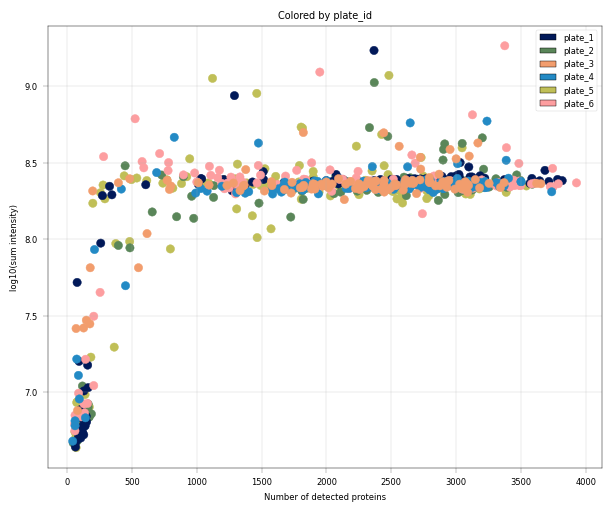

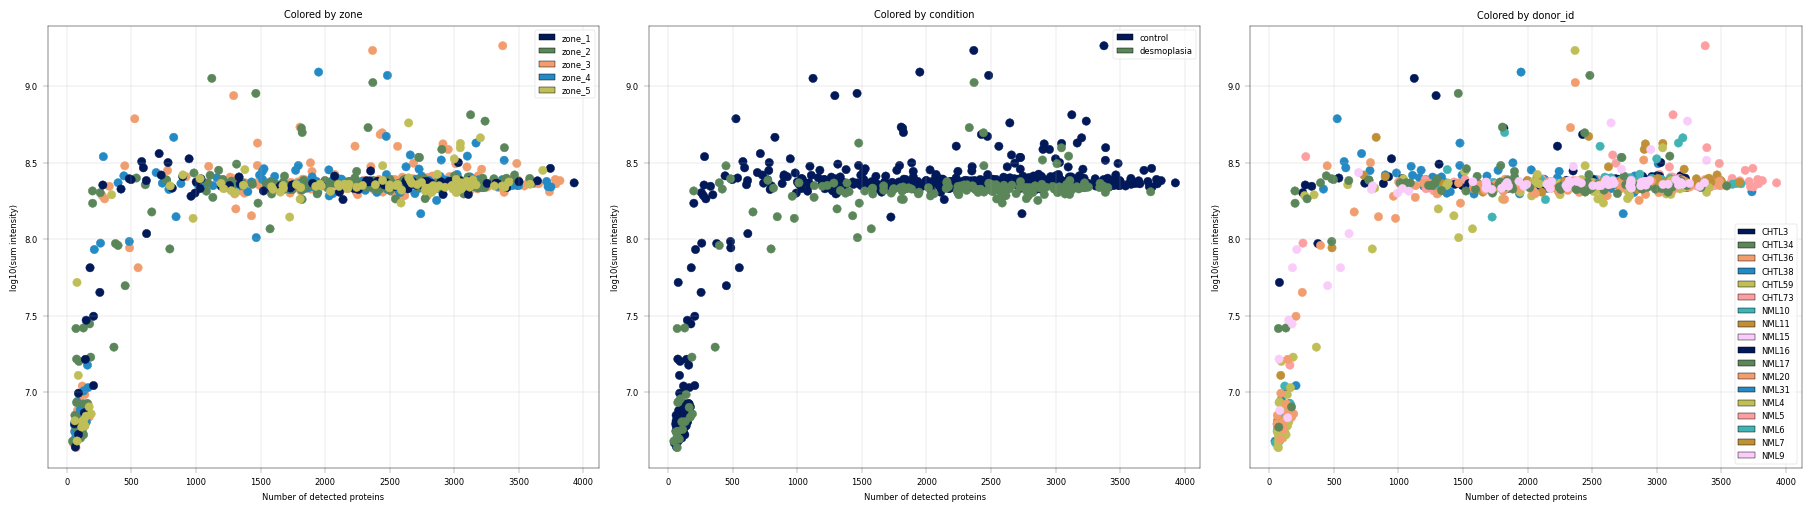

In [14]:
# Scatter plot: Detection vs Intensity, colored by technical and biological covariates

# Scatter plot for technical covariate
fig, axm = apt.pl.create_figure(1, 1, figsize=(6, 5))
ax = axm.next()
apt.pl.scatter(
    data=adata.obs,
    x_column="num_features_detected",
    y_column="log10_sum_intensity",
    ax=ax,
    color_map_column=technical,
    legend="auto",
)
apt.pl.label_axes(
    ax,
    xlabel="Number of detected proteins",
    ylabel="log10(sum intensity)",
    title=f"Colored by {technical}",
)

# Scatter plots for the biological covariate (color by different columns)
# --> as before, handle the plotting with a small loop over the columns we want to highlight
fig, axm = apt.pl.create_figure(1, 3, figsize=(18, 5))
for color_column in [biological, "condition", "donor_id"]:
    ax = axm.next()
    apt.pl.scatter(
        data=adata.obs,
        x_column="num_features_detected",
        y_column="log10_sum_intensity",
        color_map_column=color_column,
        ax=ax,
        legend="auto",
    )
    apt.pl.label_axes(
        ax,
        xlabel="Number of detected proteins",
        ylabel="log10(sum intensity)",
        title=f"Colored by {color_column}",
    )

### Observation:

In this example, we can again notice the cells deviating from the main cluster. These cells have less than 500 detected proteins and lower than 10^8 sum intensity. 

### Conclusion:

Since these cells appear randomly distributed across `condition`, `donor`, `plate` and `zone`, we assume that these are low quality cells rather than an interesting subpopulations or specific batches, increasing our confidence that these cells can be filtered out.

---


## 8. Sample filtering

### Filtering Philosophy
Filtering involves a trade-off between losing datapoints and removing technical noise, both of which can affect downstream statistical analyses. Typically, the filtering threshold is set based on the QC plots and the experimental design (e.g., number of samples) and overall data quality. But how stringent should the thresholds be? In their [scRNA-seq tutorial](https://doi.org/10.15252/msb.20188746), Luecken and Theis (2019) recommend an iterative approach: start with a permissive threshold and adjust it downward if downstream analyses reveal technical artifacts. This strategy is also appropriate in the current context. 

### **8.1 Labeling sample outliers**
Following the manuscript methodology & with our preceding analyses in mind, we:
- remove samples with very low protein detection
- remove outliers identified in QC plots
- ensure each condition/zone has sufficient representation


For sample filtering, we orient ourselves on the manuscript, where Z scores of the number of proteins detected per sample were used to label outliers. Importantly, we introduce a small change, and use MAD (median absolute deviation) to calculate a non-parametric
equivalent of the Z-score, which is considered to be more robust, as suggested by Heumos et al. in their [multi-modal single cell best practices](https://doi.org/10.1038/s41576-023-00586-w). Taking this into account, we can define outliers for our analysis:

- "An outlier is a sample with a MAD-score above 3 or below -3"

These cutoff values sreve as general guidelines and are not fixed. Thresholds should be adjusted based on the distribution and characteristics of the dataset.

For the calculation, we replace the _mean_ and _standard deviation_ in the z-score formula with the _median_ and the _median absolute deviation_. Therefore,

$$\text{z-score} = \frac{\text{value} - \text{mean}}{\text{std}}$$

becomes

$$\text{MAD-score} = \frac{\text{value} - \text{median}}{\text{MAD}}$$

  adata.obs["sample_absolute_deviation"] = np.abs(adata.obs["num_features_detected"] - median_proteins)



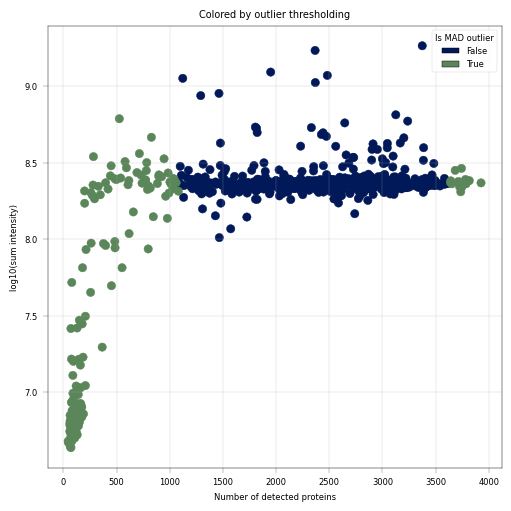

In [15]:
# Calculate the median absulte deviation (MAD) for the number of detected proteins

# First, compute the median protein count across all samples (scalar)
median_proteins = np.median(adata.obs["num_features_detected"])

# Second, compute the absolute deviation from the median for each sample (vector, we use this instead of subtracting the mean as we would for z-scores)
adata.obs["sample_absolute_deviation"] = np.abs(adata.obs["num_features_detected"] - median_proteins)

# Third, compute the median of these deviations (actual MAD statistic, scalar, which we use instead of std)
mad_proteins = np.median(adata.obs["sample_absolute_deviation"])

# Fourth, compute MAD-normalized score (similar to z-score but using median/MAD instead of mean/std)
adata.obs["num_proteins_MAD"] = (adata.obs["num_features_detected"] - median_proteins) / mad_proteins

# mark outliers
LOW = -2
HIGH = 2
adata.obs["is_outlier"] = (adata.obs["num_proteins_MAD"] < LOW) | (adata.obs["num_proteins_MAD"] > HIGH)

# Plot proteins that are outliers according to MAD thresholding
fig, axm = apt.pl.create_figure(1, 1, figsize=(5, 5))

ax = axm.next()
apt.pl.scatter(
    data=adata.obs,
    x_column="num_features_detected",
    y_column="log10_sum_intensity",
    color_map_column="is_outlier",
    ax=ax,
    legend="auto",
    legend_kwargs={"title": "Is MAD outlier"},
)
apt.pl.label_axes(
    ax,
    xlabel="Number of detected proteins",
    ylabel="log10(sum intensity)",
    title="Colored by outlier thresholding",
)

### Observation:

A small fraction of samples has critically few detected proteins, whcih also coincides with much (up to more than one order of magnitude) lower sum intensity.

### Conclusion:

We decide to remove these outlier samples and keep samples with roughly constant intensity and protein detection numbers

### **8.2 Remove sample outliers**

Once labeled and visualized, we are confident we can remove the outliers, which have generally low sum intensity and low numbers of proteins detected.

In [16]:
# create a copy of the original adata, and filter out the outlier samples
adata_unfiltered = adata.copy()
adata = adata_unfiltered[~adata_unfiltered.obs["is_outlier"], :].copy()

print(f"Remaining samples before outlier removal: {adata_unfiltered.n_obs}")
print(f"Remaining samples after outlier removal: {adata.n_obs}")

Remaining samples before outlier removal: 769
Remaining samples after outlier removal: 618


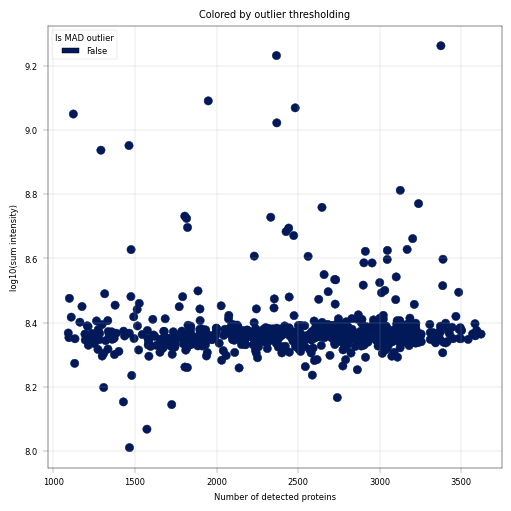

In [17]:
fig, axm = apt.pl.create_figure(1, 1, figsize=(5, 5))

ax = axm.next()
apt.pl.scatter(
    data=adata.obs,
    x_column="num_features_detected",
    y_column="log10_sum_intensity",
    color_map_column="is_outlier",
    ax=ax,
    legend="auto",
    legend_kwargs={"title": "Is MAD outlier"},
)
apt.pl.label_axes(
    ax,
    xlabel="Number of detected proteins",
    ylabel="log10(sum intensity)",
    title="Colored by outlier thresholding",
)

---

## 9. Missing Value Analysis and Protein QC

  ### Understanding Missing Values in Proteomics

  Missing values in low input DIA data acquisition are considered to be missing not at random (MNAR), meaning that the missingness is (largely) dependent on the abundance level of the protein - low-abundance proteins are more likely to be missing. This has been investigated in detail, and an excellent definition/summary and implementation is given in a [paper by Li et al.](https://www.biorxiv.org/content/10.1101/2025.04.28.651125v1.full.pdf) In practice, this means that different missingness patterns may require different imputation strategies.

  ### Why This Matters

  - **Don't impute blindly**: Simple imputation (e.g., zeros) can distort biological signal
  - **Missing patterns can indicate batch effects**: Different batches may have different detection thresholds
  - **Filtering may be necessary**: Proteins with too many missing values are unreliable for statistical testing

  ### Protein-Level Missing Values

  Beyond sample filtering, we also need to evaluate protein-level missingness. In our `calculate_qc_metrics` function we also calculated the summed intensity of each protein, and the number of fractions of samples in which the proteins were detected. Here we will evaluate these values. Proteins vary widely in their detection frequency - some are detected in all samples (the "core proteome"), while others appear only sporadically. Analyzing protein completeness (the fraction of samples in which each protein is detected) informs several critical decisions:

  1. **Filtering thresholds**: Which proteins should be excluded based on detection frequency (e.g., proteins detected in < X% of samples)?
  2. **Imputation strategies**: Proteins with different missingness rates may require different imputation approaches
  3. **Statistical power**: Proteins with extensive missing values yield less reliable statistical inferences

  We will plot the distribution of protein completeness to understand the overall detection landscape and guide filtering decisions.


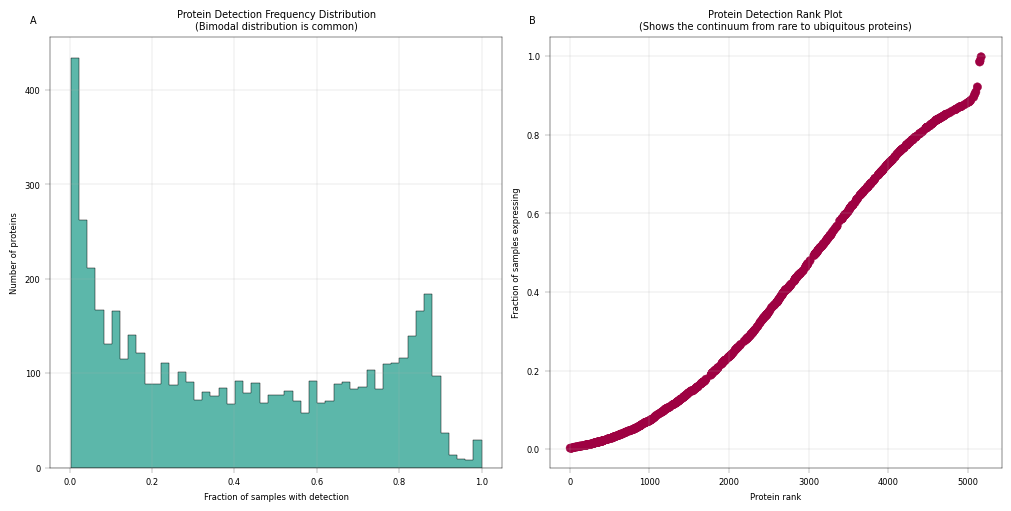

In [18]:
# Histogram of detection frequency combined with a rank plot
fig, axm = apt.pl.create_figure(1, 2, figsize=(10, 5))

# Histogram
ax = axm.next()
apt.pl.histogram(
    data=adata,
    value_column="fraction_detected_samples",
    bins=50,
    ax=ax,
    color=apt.pl.BaseColors.get("green"),
    hist_kwargs={"histtype": "stepfilled", "edgecolor": "black"},
)

apt.pl.label_axes(
    ax,
    xlabel="Fraction of samples with detection",
    ylabel="Number of proteins",
    title="Protein Detection Frequency Distribution\n(Bimodal distribution is common)",
    enumeration="A",
)

# Rank plot
protein_ranks = np.argsort(np.argsort(adata.var["fraction_detected_samples"]))
adata.var["protein_rank"] = protein_ranks

ax = axm.next()
apt.pl.scatter(
    data=adata,
    x_column="protein_rank",
    y_column="fraction_detected_samples",
    ax=ax,
    color=apt.pl.BaseColors.get("red"),
)
apt.pl.label_axes(
    ax,
    xlabel="Protein rank",
    ylabel="Fraction of samples expressing",
    title="Protein Detection Rank Plot\n(Shows the continuum from rare to ubiquitous proteins)",
    enumeration="B",
)

### Observation:

In panel A: We observe a bimodal distribution of proteins, where a large number of proteins is almost never detected, and a second peak shows up for proteins that are very frequently or always detected.
In panel B: There is a steep initial decline from the most detected protein (right), to the least detected ones. Aside from that, the missingness trend appears roughly linear.

### Conclusion

Most proteins are not consistently detected across all samples. Instead, protein detection varies between samples, likely reflecting underlying biological variability, where differences in cellular composition, physiological states, or regulatory activity result in distinct protein detection patterns across samples. Nonetheless, proteins detected in only a small fraction of samples may introduce technical noise and contribute limited analytical value due to their sparsity. Therefore, filtering proteins with low detection or completion rates can improve data robustness.

### **9.1 Missing Values vs. Abundance**

This is a key diagnostic plot in proteomics QC. It demonstrates that missing values are **not random** - they correlate with protein abundance.
This can help us asses the more "reliable" abundance levels, in which most of the proteins are above detection limit in most of the samples.

**Expected pattern:** Low-abundance proteins have more missing values (MNAR behavior)

**Implications:**
- Statistical tests should account for this systematic missingness
- Consider abundance-aware imputation methods if imputation is necessary

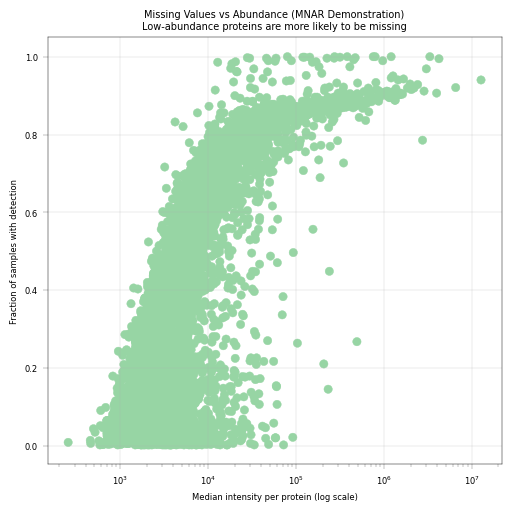

In [19]:
# Missing fraction vs median intensity per protein
# This plot demonstrates the MNAR (Missing Not At Random) nature of proteomics data
fig, axm = apt.pl.create_figure(1, 1, figsize=(5, 5))

median_intensity_per_protein = np.nanmedian(adata.X, axis=0)
adata.var["median_intensity"] = median_intensity_per_protein

# Log plot
ax = axm.next()
apt.pl.scatter(
    data=adata.var,
    x_column="median_intensity",
    y_column="fraction_detected_samples",
    color=apt.pl.BaseColors.get("lightgreen"),
    ax=ax,
)
ax.set_xscale("log")
apt.pl.label_axes(
    ax,
    xlabel="Median intensity per protein (log scale)",
    ylabel="Fraction of samples with detection",
    title="Missing Values vs Abundance (MNAR Demonstration)\nLow-abundance proteins are more likely to be missing",
)

### Observation:

Proteins show a correlation between missingness and median intensity.

### Conclusion:

Our missing values appear to be not entirely random, but correlated to the protein abundance. This is in line with [literature](https://www.biorxiv.org/content/10.1101/2025.04.28.651125v1.full.pdf), and represents a key feature of proteomics and especially low-input proteomics.


### **9.2 Visualizing the Proteome Landscape**

Having established that missingness is abundance-dependent, we can now examine the overall distribution of protein abundances across the dataset. A rank plot orders proteins from most to least abundant (or most to least frequently detected), revealing:
  - The dynamic range of protein detection: A hallmark feature of proteomics is the high dynamic range in the intensity of detected features. In regular expression proteomics datasets, spanning 5+ orders of magnitude is common.
  - Natural thresholds for filtering low-abundance proteins
  - The "tail" shows the low end of detection


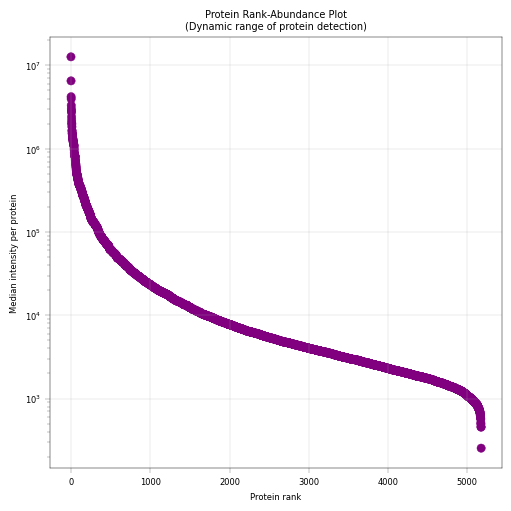

In [20]:
# Rank-median plot: Shows the dynamic range of protein abundances
fig, axm = apt.pl.create_figure(1, 1, figsize=(5, 5))
ax = axm.next()

# Add rank to protein dataset and reorder proteins by median intensity
adata.var["protein_rank"] = np.argsort(np.argsort(-adata.var["median_intensity"]))  # negative sign for descending order

# Simple median rank plot
apt.pl.scatter(
    ax=ax, data=adata.var, x_column="protein_rank", y_column="median_intensity", color=apt.pl.BaseColors.get("purple")
)
ax.set_yscale("log")

apt.pl.label_axes(
    ax,
    xlabel="Protein rank",
    ylabel="Median intensity per protein",
    title="Protein Rank-Abundance Plot\n(Dynamic range of protein detection)",
)

### Observations

The proteome spans approximately 5 orders of magnitude in abundance, with few highly abundant proteins (median intensity > 10^6) and few very-low abundance proteins (median intensity < 10^3) 

  ### Conclusions

  Based on this distribution:
  **Filtering threshold**: Consider excluding very-low abundance proteins to focus on reliably quantified proteins
  **Statistical considerations**: The long tail of low-abundance proteins will have limited statistical power and should be interpreted with caution


---


## 10. Protein Filtering

Similar to sample filtering, protein filtering requires defining an appropriate threshold for protein inclusion. Typically, proteins detected in only a small fraction of samples are removed. However, this threshold should account for dataset heterogeneity, as it may not be realistic to expect all proteins to be detected across all samples. A practical strategy is to begin with a relatively permissive threshold (e.g., retaining proteins detected in at least 20% of samples) and then iteratively apply more stringent cutoffs to evaluate their impact on the analysis.

Following the manuscript: "...an additional filtering criterion at the protein level was applied, requiring proteins to be detected in at least 70% of samples..." - we will apply the same threshold here.
Based on the QC plots, this threshold would remove more than 50% of the proteins. Alternative approaches include using less stringent thresholds and iteratively adjust according to downstream evaluations, or applying imputation. Even when imputation is used, it is still recommended to remove proteins with very low coverage.

**Why this threshold?**
- Reduces noise from sporadic detections
- Creates a reliable "proteome" for downstream analyses



INFO:root:pp.filter_data_completeness(): flag 3426 / 5175 features with >0.30 missing fraction.


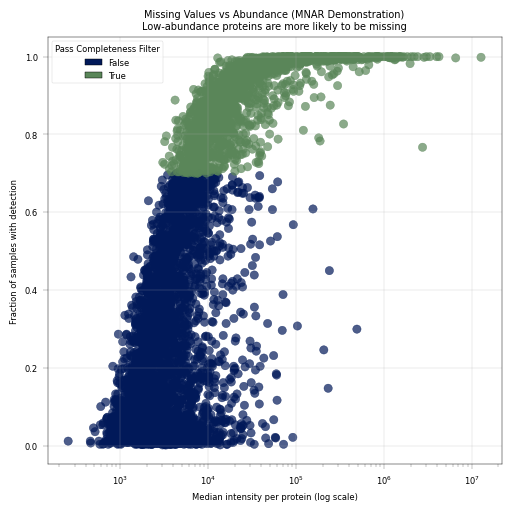

In [21]:
# Recalculate data completeness per protein as the fraction of samples with non-missing values in the filtered dataset
adata.var["fraction_detected_samples"] = np.sum(~np.isnan(adata.X), axis=0) / adata.n_obs

# By running data completeness filtering with the 'flag' action, we can see which proteins would be filtered out at a given threshold
adata = apt.pp.filter_data_completeness(adata, max_missing=0.3, action="flag", var_colname="pass_completeness_filter")

# Visualize removed proteins based ontheir median intensity
fig, axm = apt.pl.create_figure(1, 1, figsize=(5, 5))
ax = axm.next()

apt.pl.scatter(
    data=adata.var,
    x_column="median_intensity",
    y_column="fraction_detected_samples",
    color_map_column="pass_completeness_filter",
    legend="auto",
    ax=ax,
    legend_kwargs={"title": "Pass Completeness Filter"},
    scatter_kwargs={"alpha": 0.7},
)

ax.set_xscale("log")

apt.pl.label_axes(
    ax,
    xlabel="Median intensity per protein (log scale)",
    ylabel="Fraction of samples with detection",
    title="Missing Values vs Abundance (MNAR Demonstration)\nLow-abundance proteins are more likely to be missing",
)

In [22]:
# now we filter the proteins to keep only those detected in 70% of samples
print(f"Proteins before filtering for 70% completeness: {adata.n_vars}")
adata = apt.pp.filter_data_completeness(adata, max_missing=0.3, action="drop")
print(f"Remaining proteins after filtering for 70% completeness: {adata.n_vars}")

INFO:root:pp.filter_data_completeness(): drop 3426 / 5175 features with >0.30 missing fraction.


Proteins before filtering for 70% completeness: 5175
Remaining proteins after filtering for 70% completeness: 1749


---


## 11. Biological Validation and Quality Assessment

Following technical quality control (e.g., assessment of missing values and protein abundance distributions), it is important to verify that the dataset captures expected biological signals. Sanity checks based on prior knowledge of the biological system provide a useful approach for evaluating the dataset’s ability to reflect meaningful biological variation. High-quality proteomics datasets should demonstrate:

1. **Biological signal preservation**: Known biological patterns should be detectable (e.g., spatially zonated gene expression in liver)
2. **Technical reproducibility**: Similar cells should have similar protein profiles (low coefficient of variation within cell types)
3. **Cell type separation**: Distinct cell populations should be distinguishable in reduced-dimension space (such as PCA)

  ### Why These Validations Matter

**Zonated Gene Expression** provides a biological "ground truth" for liver samples. Hepatocytes display spatial zonation along the portal-central axis:
  - Portal zone: Enriched for oxidative metabolism, amino acid catabolism (e.g., ASS1, CPS1)
  - Central zone: Enriched for glycolysis, lipogenesis, xenobiotic metabolism (e.g., GLUL, CYP2E1)
  - If the data recapitulates these known patterns, it validates biological signal preservation

  **Coefficient of Variation (CV)** 
   - Quantifies measurement reproducibility. biological replicates should have low CVs (indicating a relaibale and reprodicble measurement despite the technical nouse). 
   - We also expect biological replicates to have lower CVs than different biological conditions. 

  **Principal Component Analysis (PCA)** reveals the dominant sources of variation:
  - Should separate known cell types or biological conditions
  - Can reveal batch effects or technical artifacts if they dominate over biology
  - Indicates whether sufficient biological information is retained after QC filtering

  Together, these analyses confirm that our dataset is technically sound and biologically meaningful before proceeding to downstream analyses.


As the study focuses on the hepatocytes from healthy donors to assess zonation, we will first subset the `adata` to include only `control` cells.

In [23]:
adata = adata[adata.obs["condition"] == "control"].copy()
adata

AnnData object with n_obs × n_vars = 483 × 1749
    obs: 'id', 'score', 'donor_id', 'plate_id', 'condition', 'geometry_id', 'zone', 'total_sample_intensity', 'num_features_detected', 'fraction_detected_features', 'log10_sum_intensity', 'sample_absolute_deviation', 'num_proteins_MAD', 'is_outlier'
    var: 'Protein.Group', 'Protein.Names', 'Genes', 'total_feature_intensity', 'num_samples_detected', 'fraction_detected_samples', 'protein_rank', 'median_intensity', 'pass_completeness_filter'

### **11.1 Detailed sanity checks using individual proteins**

If there are **known biological markers** or **expected patterns**, checking their distributions is a good and fast way to test how well the data meet the biological expections from existing knowledge. This kind of sanity check is an essential counterpart to technical QC metrics, since a well-executed sample preparation and measurement is independent from the validity of the biological study setup.

**For liver peotein zonation data, we expect:**
- **CYP2E1, GLUL**: Central zone markers, should be higher in zone 5 and gradually decreasing.
- **CPS1, ASS1**: Periportal markers, should be higher in zone 1 and gradually decreasing.

**What to check:**
1. Do known markers show expected biological patterns?
2. Are distributions similar across technical batches (after accounting for biology)?

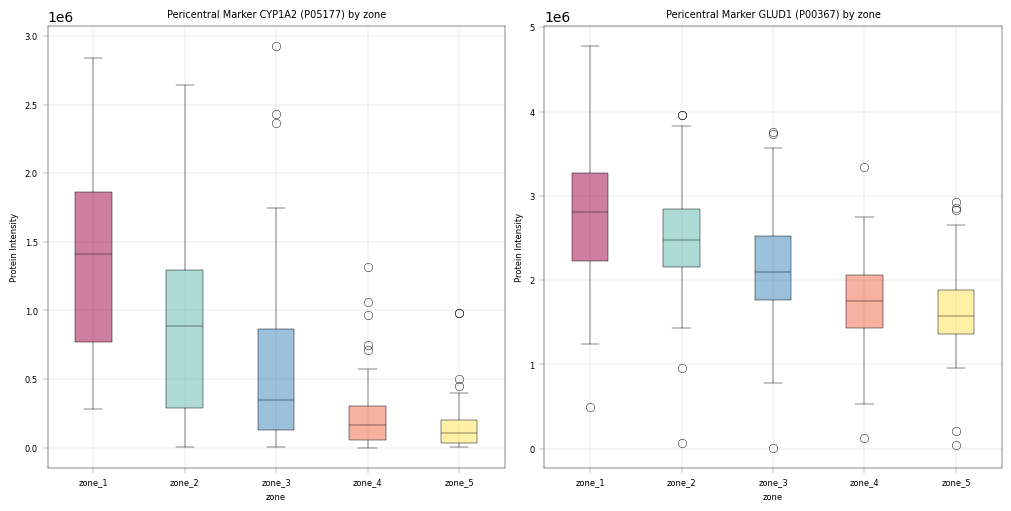

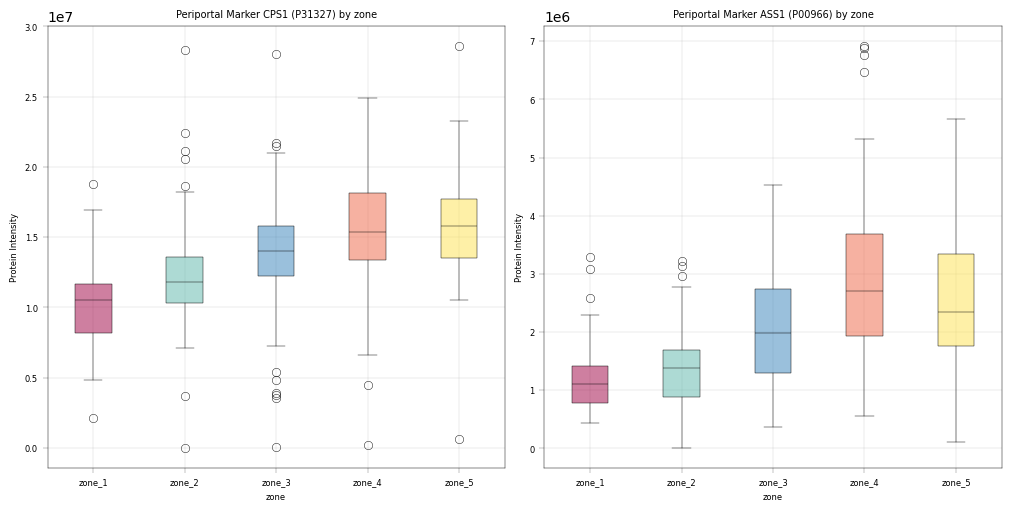

In [24]:
# Check distribution of known marker proteins

pericentral = {"P05177": "CYP1A2", "P00367": "GLUD1"}  # CYP1A2, GLUD1
periportal = {"P31327": "CPS1", "P00966": "ASS1"}  # CPS1, ASS1

# Set up plots to visualize marker proteins with boxplots
fig, axm = apt.pl.create_figure(1, 2, figsize=(10, 5))
for pericentral_marker, pericentral_marker_gene in pericentral.items():
    # Get the corresponding column slice
    adata_pericentral = adata[:, [pericentral_marker]]

    # Order by biological covariate
    bio_order = adata_pericentral.obs[biological].argsort()
    adata_pericentral = adata_pericentral[bio_order, :]

    ax = axm.next()
    apt.pl.boxplot(
        ax=ax,
        data=adata_pericentral,
        grouping_column=biological,
        value_column=pericentral_marker,
        color_dict=biological_color_dict,
    )

    apt.pl.label_axes(
        ax,
        title=f"Pericentral Marker {pericentral_marker_gene} ({pericentral_marker}) by {biological}",
        xlabel=biological,
        ylabel="Protein Intensity",
    )

fig, axm = apt.pl.create_figure(1, 2, figsize=(10, 5))
for periportal_marker, periportal_marker_gene in periportal.items():
    # Get the corresponding column slice
    adata_periportal = adata[:, [periportal_marker]]

    # Order by biological covariate
    bio_order = adata_periportal.obs[biological].argsort()
    adata_periportal = adata_periportal[bio_order, :]

    ax = axm.next()
    apt.pl.boxplot(
        ax=ax,
        data=adata_periportal,
        grouping_column=biological,
        value_column=periportal_marker,
        color_dict=biological_color_dict,
    )

    apt.pl.label_axes(
        ax,
        title=f"Periportal Marker {periportal_marker_gene} ({periportal_marker}) by {biological}",
        xlabel=biological,
        ylabel="Protein Intensity",
    )

### Observation:

For these markers we could observe the expected patterns. An especially good sign is that these patterns show up even before filtering data, which alludes to a core tenet in proteomics analyses: In our experience, strong biological signal is always there and only enhanced by filtering / preprocessing. If a study fails to meet critical biological assumptions from the get-go, it is a sign to interpret the data with caution. And sanity check the experimental setup and workflow to ensure that the data at hand is plausible.

### Conclusion:

Since key markers show expected trends across the biological covariate `zone`, we assume that the data is in principle trustworthy and that valid conclusions can be drawn in further analyses.

### **11.2 Coefficient of Variation (CV) Analysis**

### What is CV?

The **Coefficient of Variation** measures relative variability:

$$CV = \frac{\text{Standard Deviation}}{\text{Mean}} \times 100\%$$

### Considertions for CVs in proteomics

- Lower CV = more reproducible measurements
- Technical replicates should have CV < 20% (empirical threshold for tolerable workflow imprecision)

### Common practice in CV evaluation 

| CV Range | Interpretation |
|----------|----------------|
| < 10% | Excellent reproducibility |
| 10-30% | Good, typical for biological replicates |
| 30-50% | Acceptable for some applications |
| > 50% | High variability, interpret with caution |

Note: These CV ranges represent commonly used benchmarks in the field rather than strict or universally accepted thresholds, and should be interpreted in the context of the experimental design and data quality.

### CV vs abundance

Low-abundance proteins typically have higher CV due to:
- Measurement noise is larger relative to signal
- Stochastic sampling effects
- Near-detection-limit variability

This relationship is known and important; [some imputation methods](https://www.biorxiv.org/content/10.1101/2025.04.13.648568v1) try to consider this relationship of variance & abundance in the way they model missing values.


Because this dataset includes cells derived from different individuals, defining true technical replicates is not straightforward, as variability within a given group may reflect biological differences rather than technical noise. Nevertheless, it is reasonable to expect that variability within more homogeneous groups (e.g., within each zone and donor) would be lower than the overall variability across the entire dataset. In the following section, we will calculate and visualize protein CVs across all conditions as well as within each zone and donor and compare the results.

In [25]:
# Calculate CV for each protein using alphapepttools
apt.metrics.coefficient_of_variation(
    adata,
    key_added="CV",
    min_valid=3,
)

# inspect CV values
display(adata.var[["CV"]].head(10))

,CV
uniprot_ids,
A0A0B4J2D5;P0DPI2,0.329995
A0A0J9YWP8,0.960993
A0AVT1,0.408088
A0MZ66,0.452652
A1L0T0,0.436763
A2A2Z9,0.377783
A2VDF0,0.409117
A3KMH1,0.494791
A6NCW0;A8MUK1;C9J2P7;C9JJH3;C9JPN9;C9JVI0;D6R901;D6R9N7;D6RA61;D6RBQ6;D6RCP7;D6RJB6;Q0WX57;Q7RTZ2,2.363135


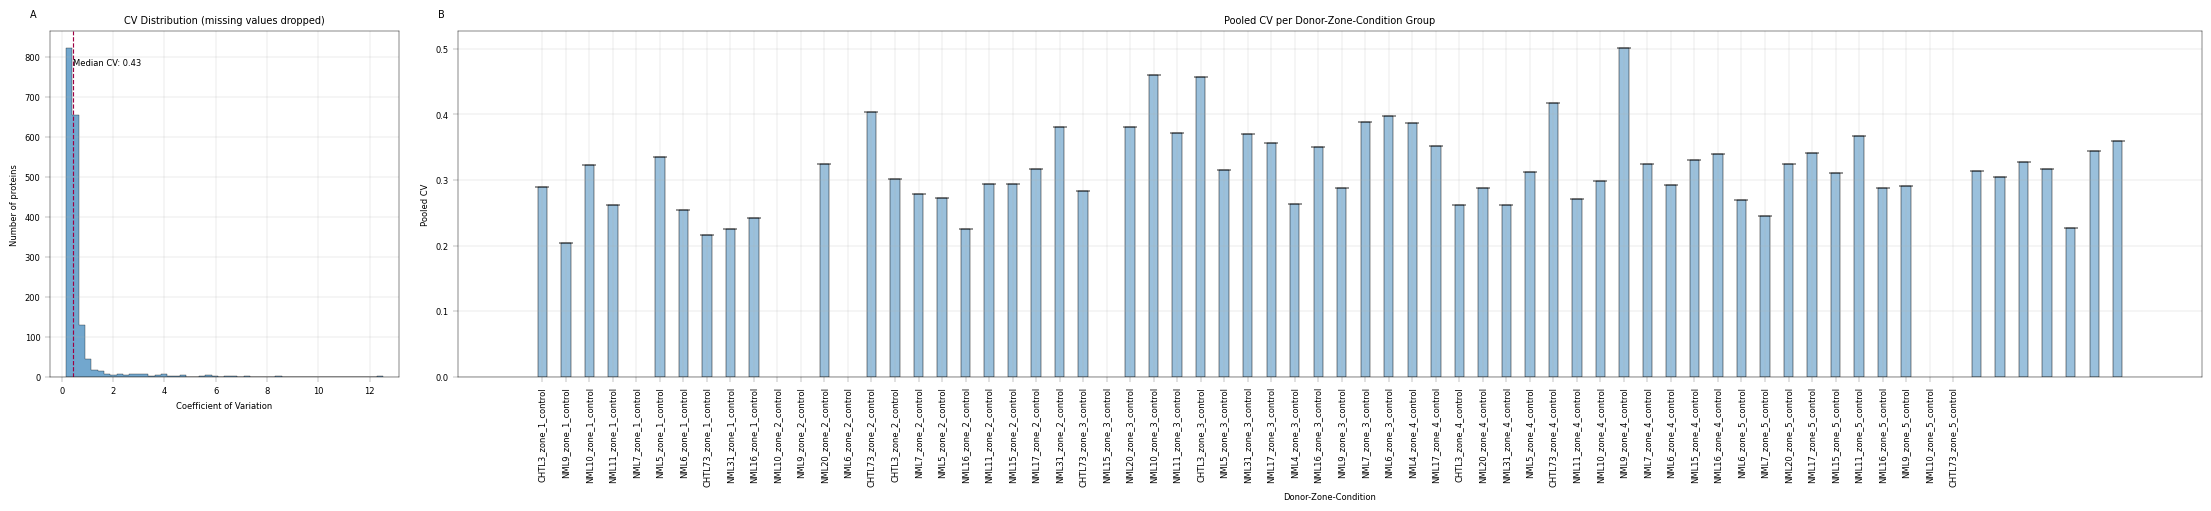

In [26]:
# CV distribution histogram
# make right window twice the width
fig, axm = apt.pl.create_figure(1, 2, figsize=(22, 5), gridspec_kwargs={"width_ratios": [1, 5]})

# Show the CV distribution across all proteins, disregarding replicates
ax = axm.next()
apt.pl.histogram(
    data=adata.var,
    value_column="CV",
    bins=50,
    ax=ax,
    hist_kwargs={"histtype": "stepfilled", "edgecolor": "black", "alpha": 0.7},
)

median_cv = adata.var["CV"].median()

apt.pl.add_lines(
    ax,
    intercepts=[median_cv],
    linetype="vline",
    linestyle="--",
    color=apt.pl.BaseColors.get("red"),
)

# add the labels for the median CV line
label_df = pd.DataFrame(
    {"x": [median_cv + 0.02], "y": [ax.get_ylim()[1] * 0.9], "label": [f"Median CV: {median_cv:.2f}"]}
)

apt.pl.label_plot(
    ax,
    data=label_df,
    x_column="x",
    y_column="y",
    label_column="label",
)

apt.pl.label_axes(
    ax,
    xlabel="Coefficient of Variation",
    ylabel="Number of proteins",
    title="CV Distribution (missing values dropped)",
    enumeration="A",
)

# Focus on individual replicates: CV per protein in each donor_id - zone - condition group
adata.obs = adata.obs.copy()
adata.obs["donor_zone_condition"] = (
    adata.obs["donor_id"].astype(str) + "_" + adata.obs["zone"].astype(str) + "_" + adata.obs["condition"].astype(str)
)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    pooled_cvs = apt.metrics.pooled_coefficient_of_variation(
        adata,
        group_column="donor_zone_condition",
        min_valid=3,
        inplace=False,
    )

if "pcv" not in adata.obs.columns:
    adata.obs = adata.obs.copy()
    adata.obs = adata.obs.merge(
        pooled_cvs,
        left_on="donor_zone_condition",
        right_index=True,
        how="left",
    )

ax = axm.next()
apt.pl.barplot(
    ax=ax,
    data=adata,
    grouping_column="donor_zone_condition",
    value_column="pcv",
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")

apt.pl.label_axes(
    ax,
    title="Pooled CV per Donor-Zone-Condition Group",
    xlabel="Donor-Zone-Condition",
    ylabel="Pooled CV",
    enumeration="B",
)

plt.show()

### Observation:

Median CV without considering replicates is high (49%), but a more differentiated picture emerges when individual treatment groups are plotted. NML31 zone 4 exhibits unusually high CVs, which may warrant their exclusion.

### Conclusion:

Collective CVs are rather uninformative, but group-wise CVs per replicate identify problematic entries.



### **11.3 CV vs. mean** 

We saw that the CV is used to assess reproducibility and stability of the data when chacked **across replicates**. 
Between different biological/experimetal groups, high CV can indicate that these proteins are differentially expressed. 
Also, highly variable proteins are the main drivers of many downstream analyses (such as PCA and clustering). Therefore, it is useful to check the protein variabilty. To do so, we can plot the CV against the mean abundance. In proteomics, we usually expect a negative correlation, that is high CV <=> lower mean, indicating that the lowest abundant proteins are also the most variable ones.
Since NaN values should not be dropped in this analysis (dispersion also depends on the number of samples), we will assign minimal value to NaNs and calculate the CV and mean on thapt.  

### In the following analysis,
We visualize protein CV vs. mean, which enables us to spot especially variable outliers. Contaminant proteins that are present in some replicates can show up in such an analysis. For example, plasma proteomics is [sensitive to incorrect sample processing](https://www.biorxiv.org/content/10.1101/2025.05.07.652495v1.abstract), which can enrich some samples with unwanted proteins from blood cells. Unless contamination is uniform across all replicates, the contaminants would show up as high-CV outliers in an analysis such as the one below.

**What it can help us with:**
 - compare those proteins with our biological assumptions/expectations from the dataset 
 - identify potential highly variable contaminants
 - estimate abundance levels of technical noise




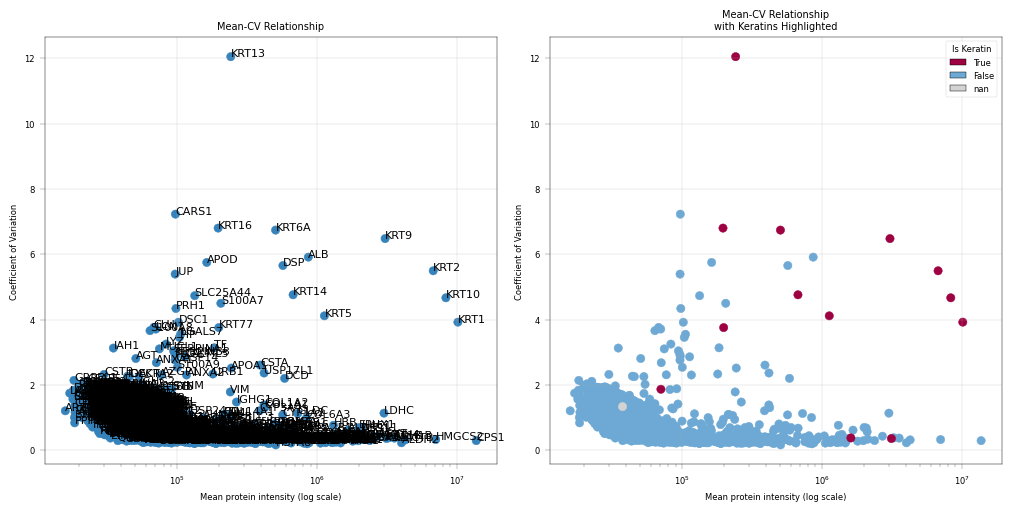

In [27]:
# Since we operate on the .X object, we first store away the original values in a separate layer
adata.layers["orig_intensity"] = adata.X.copy()

# Mean-CV relationship (classic proteomics QC plot)
MIN = np.nanmean(adata.X)
adata.X[np.isnan(adata.X)] = MIN

# store the imputed values in a separate layer, so we can easily revert back to the original data after plotting
adata.layers["min_imputed"] = adata.X.copy()

# calculate CV and mean with imputed missing values
apt.metrics.coefficient_of_variation(adata, key_added="CV_imp", min_valid=3)
adata.var["protein_mean_imp"] = np.nanmean(adata.X, axis=0)

# Set .X back to original values
adata.X = adata.layers["orig_intensity"].copy()

# Create a two-panel figure to showcase the CV vs Mean relationship
fig, axm = apt.pl.create_figure(1, 2, figsize=(10, 5))
ax = axm.next()

# First, label everything
apt.pl.scatter(
    data=adata.var,
    x_column="protein_mean_imp",
    y_column="CV_imp",
    ax=ax,
)

ax.set_xscale("log")

adata.var["single_gene_name"] = adata.var["Genes"].str.split(";").str[0].copy()

apt.pl.label_plot(
    ax=ax,
    data=adata.var,
    x_column="protein_mean_imp",
    y_column="CV_imp",
    label_column="single_gene_name",
    label_kwargs={"fontsize": 8},
)

apt.pl.label_axes(
    ax, xlabel="Mean protein intensity (log scale)", ylabel="Coefficient of Variation", title="Mean-CV Relationship"
)

# Second, focus on keratin proteins
adata.var["is_keratin"] = adata.var["single_gene_name"].str.contains("KRT")

ax = axm.next()
apt.pl.scatter(
    data=adata.var,
    x_column="protein_mean_imp",
    y_column="CV_imp",
    ax=ax,
    color_map_column="is_keratin",
    color_dict={True: apt.pl.BaseColors.get("red"), False: apt.pl.BaseColors.get("lightblue")},
    legend="auto",
    legend_kwargs={"title": "Is Keratin"},
)

ax.set_xscale("log")

apt.pl.label_axes(
    ax,
    xlabel="Mean protein intensity (log scale)",
    ylabel="Coefficient of Variation",
    title="Mean-CV Relationship\nwith Keratins Highlighted",
)

### Observation:

This plot highlights the highly variable proteins (HVPs) in the dataset. In this example, Keratins (KRT) appear among the HVPs. 

### Conclusion:

Since Keratins are known contaminants, they can be considered for removal in downstream analyses, particularly PCA, because we are not interested in variability driven by contamination.

### **11.4 Dimensionality Reduction & Variance Analysis**

### 11.4.1 PCA in Proteomics

PCA reveals the **major sources of variance** in your data. In a well-designed experiment:
- **Ideal**: Samples cluster by biological condition (zonation)
- **Problematic**: Samples cluster by technical factor (donor, plate)

### What good results look like
- Samples from same biological group cluster together
- Technical replicates are closer to each other than to other samples.

### Warning signs
- Samples cluster by batch/donor instead of biology
- Single outlier samples far from main cluster
- No clear structure (random scatter)

### Expected zonation pattern
For liver data, we expect a zonation gradient along the first PCs (usually apparent on PC1)
If PCA separates zones → biological signal preserved.

### Core Proteome for PCA

For 'vanilla' PCA, we require a complete data matrix, i.e. proteins with no missing values. Aside from imputation, filtering for the 'core proteome' accomplishes that by removing all proteins whcih have any missing values.

### Contaminant flagging
As we saw in previous figures, common proteomics contaminants are highly variable in the dataset:
- **Keratins (KRT*)**: Skin contamination from sample handling
- **Serum albumin (ALB)**: Often dominates signal, may mask other proteins
- **Hemoglobin (HB*) and immunoglobulins**: Blood contamination

We further exclude these from PCA (even if they are present in the "core proteome") as we are not interested in their variability, but keep them for total intensity calculations.


In [28]:
# Before running PCA, we will log transform the data and scale and center to run PCA
adata.X = adata.layers["orig_intensity"].copy()
apt.pp.nanlog(adata, verbosity=0)
apt.pp.scale_and_center(adata)

INFO:root:pp.scale_and_center(): Scaling data with standard scaler.


In [29]:
# Define core proteome: proteins detected in all samples, excluding contaminants

# Flag proteins with no missing values
adata = apt.pp.filter_data_completeness(adata, max_missing=0, action="flag", var_colname="is_core")

# Remove proteins outside the core proteome and known contaminants using AnnData's filtering capabilities
adata.var["prot_for_pca"] = (
    adata.var["is_core"]
    & ~(adata.var["Genes"].str.startswith("KRT", na=False))
    & ~(
        adata.var["Genes"].str.startswith("ALB", na=False)
    )  # although Alb is a liver Gene, protein level is likely a contaminant in the dataset (from blood)
    & ~(adata.var["Genes"].str.startswith("DSP", na=False))  # skin protein contaminant
    & ~(adata.var["Genes"].str.startswith("DCD", na=False))  # skin protein contaminant
    & ~(adata.var["Genes"].str.startswith("IGG", na=False))
)

print(f"{adata.var['prot_for_pca'].sum()} proteins detected in all samples, excluding contaminants")

INFO:root:pp.filter_data_completeness(): flag 1554 / 1749 features with >0 missing values.


184 proteins detected in all samples, excluding contaminants


In [30]:
# Run PCA on core proteome
apt.tl.pca(adata, meta_data_mask_column_name="prot_for_pca")

INFO:alphapepttools.tl.embeddings:computing PCA


  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)



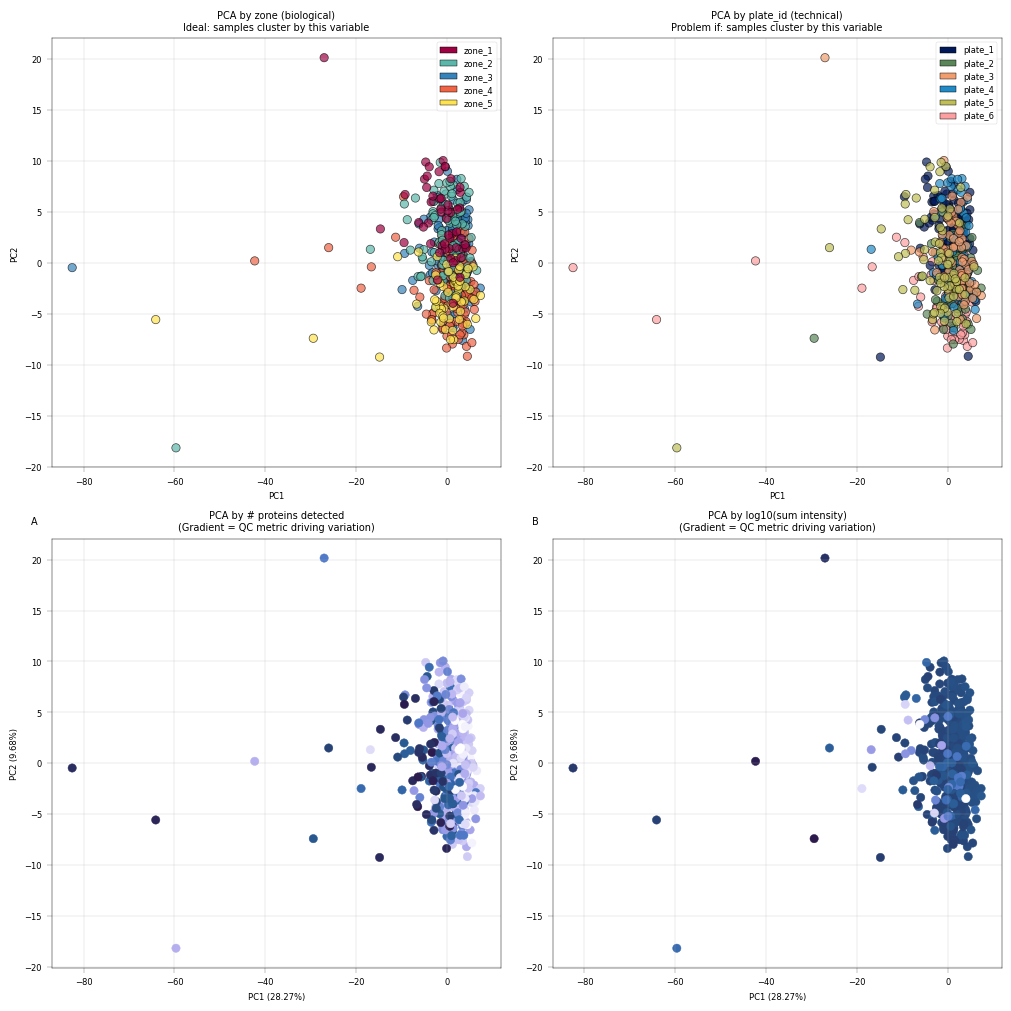

In [31]:
# PCA colored by biological and technical covariates
fig, axm = apt.pl.create_figure(2, 2, figsize=(10, 10))

# By biological covariate
ax = axm.next()
apt.pl.plot_pca(
    ax=ax,
    data=adata,
    x_column=1,
    y_column=2,
    label=False,
    color_map_column=biological,
    color_dict=biological_color_dict,  # keep coloring consistent with previous plots
    legend="auto",
    scatter_kwargs={"alpha": 0.7, "linewidth": 0.5, "edgecolor": "black"},
)
apt.pl.label_axes(
    ax=ax,
    xlabel="PC1",
    ylabel="PC2",
    title=f"PCA by {biological} (biological)\nIdeal: samples cluster by this variable",
)

# By technical covariate
ax = axm.next()
apt.pl.plot_pca(
    data=adata,
    ax=ax,
    x_column=1,
    y_column=2,
    label=False,
    color_map_column=technical,
    color_dict=technical_color_dict,
    legend="auto",
    scatter_kwargs={"alpha": 0.7, "linewidth": 0.5, "edgecolor": "black"},
)
apt.pl.label_axes(
    ax=ax,
    xlabel="PC1",
    ylabel="PC2",
    title=f"PCA by {technical} (technical)\nProblem if: samples cluster by this variable",
)

# Number of proteins detected
ax = axm.next()
apt.pl.plot_pca(
    data=adata,
    ax=ax,
    x_column=1,
    y_column=2,
    label=False,
    color_map_column="num_features_detected",
    palette=apt.pl.BaseColormaps.get("sequential"),
)

# axes[0, 0].set_title("PCA by # proteins detected\n(Gradient = QC metric driving variation)")
apt.pl.label_axes(
    ax=ax,
    title="PCA by # proteins detected\n(Gradient = QC metric driving variation)",
    enumeration="A",
)

# Sum intensity
ax = axm.next()
apt.pl.plot_pca(
    data=adata,
    ax=ax,
    y_column=2,
    label=False,
    color_map_column="log10_sum_intensity",
    palette=apt.pl.BaseColormaps.get("sequential"),
)

apt.pl.label_axes(
    ax=ax,
    title="PCA by log10(sum intensity)\n(Gradient = QC metric driving variation)",
    enumeration="B",
)

plt.show()

### Observation:

Most cells cluster tightly together, with only a few outliers more widely dispersed. The PCA is largely driven by technical covariates, such as the number of detected proteins per sample. However, a zonation pattern is evident in PC2, where zones 1–2 cluster toward the top and zones 4–5 toward the bottom.

### Conclusion:

It is common in proteomics for technical covariates to drive the leading principal components in PCA. Nevertheless, biological variation should also contribute to these components, as this would enhance interpretability. A few samples appear to be outliers; however, they should not be discarded without first understanding the underlying cause. In this example, we proceed without additional filtering, as the zonation signal is already captured in the principal components.

### 11.4.2 Overlaying PCA with QC metrics

Coloring PCA by specific proteins can reveal if the known biological variation is reflected in the PCA 

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)



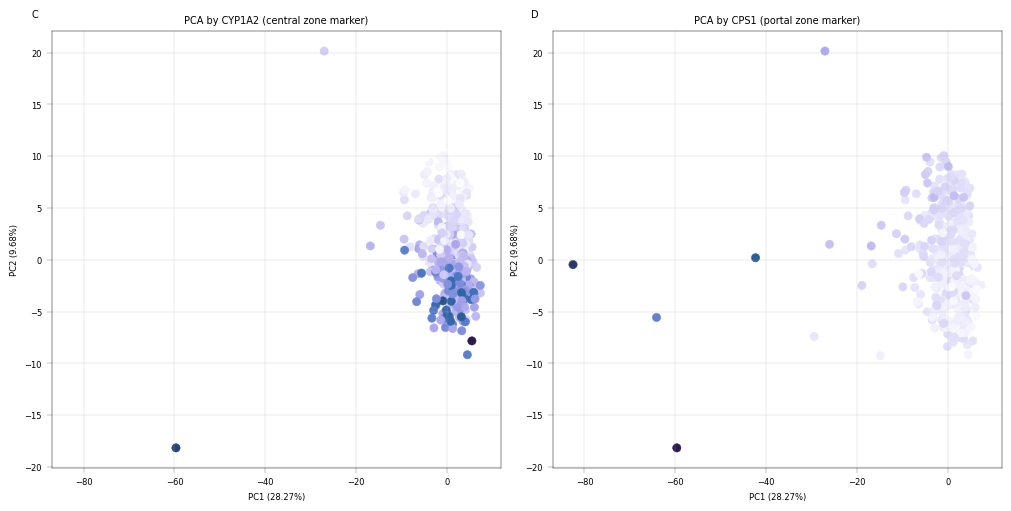

In [32]:
# PCA colored by QC metrics
fig, axm = apt.pl.create_figure(1, 2, figsize=(10, 5))


# Known marker: CYP1A2 (central zone)
ax = axm.next()
prot = "P05177"
apt.pl.plot_pca(
    data=adata,
    ax=ax,
    x_column=1,
    y_column=2,
    label=False,
    color_map_column=prot,
    palette=apt.pl.BaseColormaps.get("sequential"),
)
# axes[1, 0].set_title("PCA by CYP1A2 (central zone marker)")
apt.pl.label_axes(
    ax,
    title="PCA by CYP1A2 (central zone marker)",
    enumeration="C",
)

# Known marker: CPS1 (portal zone)
ax = axm.next()
prot = "P31327"
apt.pl.plot_pca(
    data=adata,
    ax=ax,
    x_column=1,
    y_column=2,
    label=False,
    color_map_column=prot,
    palette=apt.pl.BaseColormaps.get("sequential"),
)

apt.pl.label_axes(
    ax,
    title="PCA by CPS1 (portal zone marker)",
    enumeration="D",
)

plt.show()

The PCA plot indicates that PC1 is driven by a small number of outlier cells, while the majority of cells form a tight cluster. To reduce the influence of these outliers, we apply an additional round of cell filtering. This approach follows the strategy used by Weiss et al. for PCA preprocessing, with the exception that we use median absolute deviation (MAD)-based filtering rather than Z-scores.

Specifically, cells are removed if the expression of any protein deviates by more than ±4 MADs from that protein's median expression across all cells. This relatively stringent threshold was chosen to approximate the filtering applied in the original publication. In practice, appropriate filtering thresholds may vary across datasets and often require iterative evaluation to balance outlier removal with retention of biologically meaningful variation.

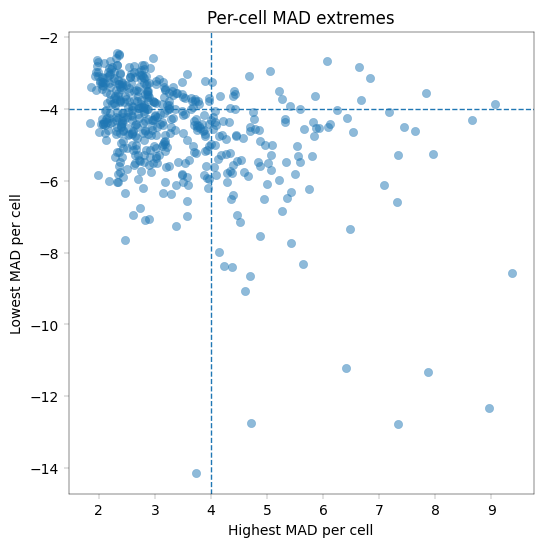

In [33]:
# on the robust scaled data
X = adata.X

threshold_mad = 4  # threshold for outlier detection based on MAD

# Per-cell max and min z-score
max_mad = np.nanmax(X, axis=1)
min_mad = np.nanmin(X, axis=1)

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(max_mad, min_mad, alpha=0.5)

plt.xlabel("Highest MAD per cell")
plt.ylabel("Lowest MAD per cell")
plt.title("Per-cell MAD extremes")
plt.axhline(-threshold_mad, linestyle="--", linewidth=1)
plt.axvline(threshold_mad, linestyle="--", linewidth=1)

plt.show()

In [34]:
adata.obs["z_outlier"] = (max_mad > threshold_mad) & (min_mad < -threshold_mad)
adata = adata[~adata.obs["z_outlier"], :].copy()

print(adata.shape)

# Define core proteome: proteins detected in all samples, excluding contaminants

# Flag proteins with no missing values
adata = apt.pp.filter_data_completeness(adata, max_missing=0, action="flag", var_colname="is_core")

# Remove proteins outside the core proteome and known contaminants using AnnData's filtering capabilities
adata.var["prot_for_pca"] = (
    adata.var["is_core"]
    & ~(adata.var["Genes"].str.startswith("KRT", na=False))
    & ~(
        adata.var["Genes"].str.startswith("ALB", na=False)
    )  # although Alb is a liver Gene, protein level is likely a contaminant in the dataset (from blood)
    & ~(adata.var["Genes"].str.startswith("DSP", na=False))  # skin protein contaminant
    & ~(adata.var["Genes"].str.startswith("DCD", na=False))  # skin protein contaminant
    & ~(adata.var["Genes"].str.startswith("IGG", na=False))
)

print(f"{adata.var['prot_for_pca'].sum()} proteins detected in all samples, excluding contaminants")

# Run PCA on core proteome
apt.tl.pca(adata, meta_data_mask_column_name="prot_for_pca")

INFO:root:pp.filter_data_completeness(): `adata.var` column 'is_core' already exists, will overwrite.
INFO:root:pp.filter_data_completeness(): flag 1190 / 1749 features with >0 missing values.
INFO:alphapepttools.tl.embeddings:computing PCA


(386, 1749)
548 proteins detected in all samples, excluding contaminants


  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)



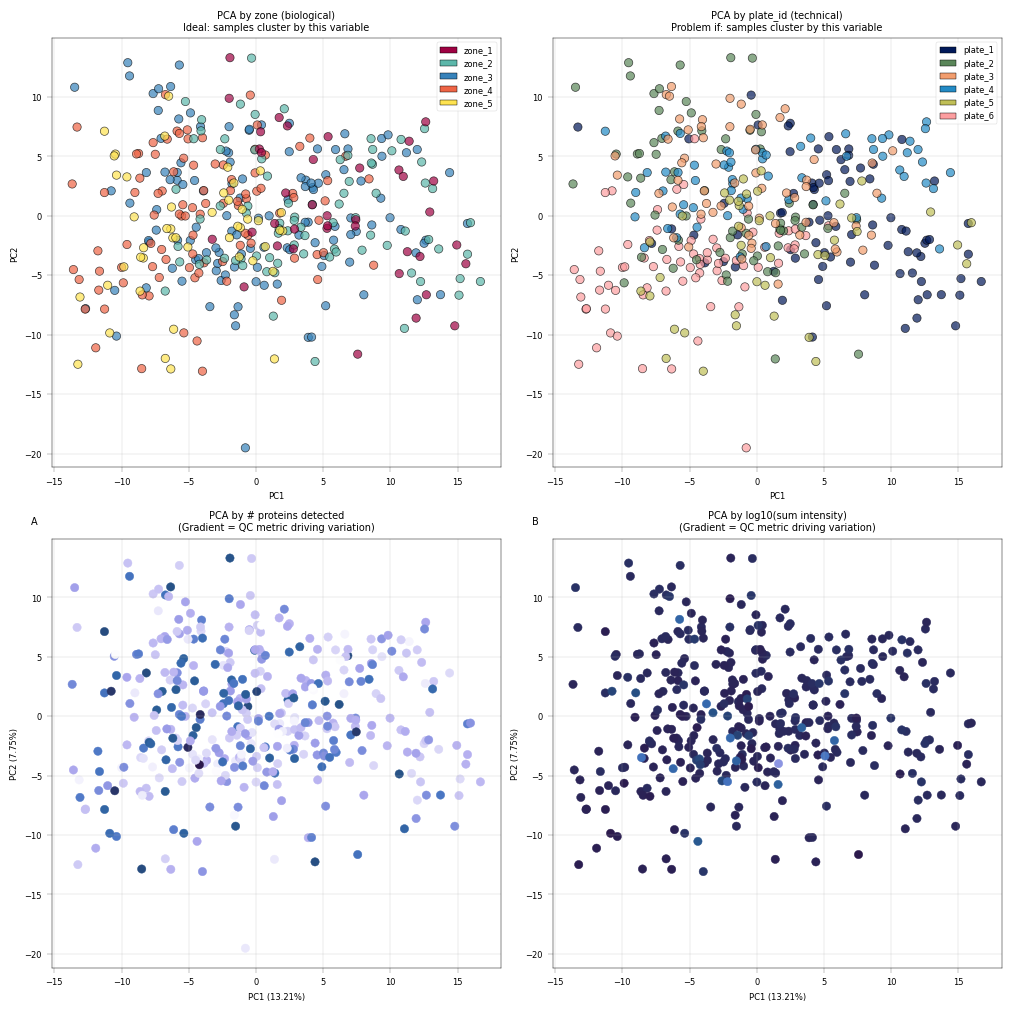

In [35]:
# PCA colored by biological and technical covariates
fig, axm = apt.pl.create_figure(2, 2, figsize=(10, 10))

# By biological covariate
ax = axm.next()
apt.pl.plot_pca(
    ax=ax,
    data=adata,
    x_column=1,
    y_column=2,
    label=False,
    color_map_column=biological,
    color_dict=biological_color_dict,  # keep coloring consistent with previous plots
    legend="auto",
    scatter_kwargs={"alpha": 0.7, "linewidth": 0.5, "edgecolor": "black"},
)
apt.pl.label_axes(
    ax=ax,
    xlabel="PC1",
    ylabel="PC2",
    title=f"PCA by {biological} (biological)\nIdeal: samples cluster by this variable",
)

# By technical covariate
ax = axm.next()
apt.pl.plot_pca(
    data=adata,
    ax=ax,
    x_column=1,
    y_column=2,
    label=False,
    color_map_column=technical,
    color_dict=technical_color_dict,
    legend="auto",
    scatter_kwargs={"alpha": 0.7, "linewidth": 0.5, "edgecolor": "black"},
)
apt.pl.label_axes(
    ax=ax,
    xlabel="PC1",
    ylabel="PC2",
    title=f"PCA by {technical} (technical)\nProblem if: samples cluster by this variable",
)

# Number of proteins detected
ax = axm.next()
apt.pl.plot_pca(
    data=adata,
    ax=ax,
    x_column=1,
    y_column=2,
    label=False,
    color_map_column="num_features_detected",
    palette=apt.pl.BaseColormaps.get("sequential"),
)

# axes[0, 0].set_title("PCA by # proteins detected\n(Gradient = QC metric driving variation)")
apt.pl.label_axes(
    ax=ax,
    title="PCA by # proteins detected\n(Gradient = QC metric driving variation)",
    enumeration="A",
)

# Sum intensity
ax = axm.next()
apt.pl.plot_pca(
    data=adata,
    ax=ax,
    y_column=2,
    label=False,
    color_map_column="log10_sum_intensity",
    palette=apt.pl.BaseColormaps.get("sequential"),
)

apt.pl.label_axes(
    ax=ax,
    title="PCA by log10(sum intensity)\n(Gradient = QC metric driving variation)",
    enumeration="B",
)

plt.show()

We can look at the assocoation between the zonation and the PCA results in nmore detail:

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)

  return dispatch(args[0].__class__)(*args, **kw)



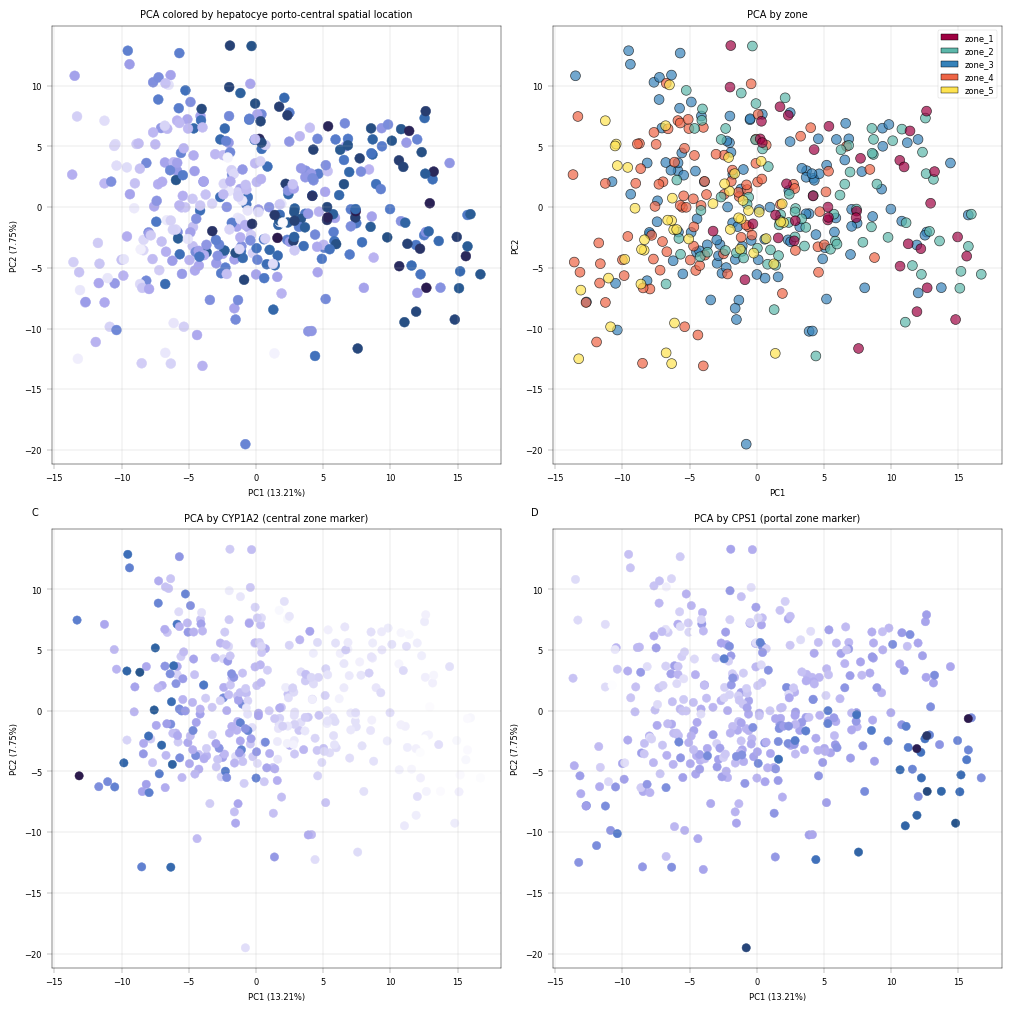

In [36]:
fig, axm = apt.pl.create_figure(2, 2, figsize=(10, 10))

ax = axm.next()
# Capture scatter object
apt.pl.plot_pca(
    data=adata,
    ax=ax,
    y_column=2,
    label=False,
    color_map_column="score",
    palette=apt.pl.BaseColormaps.get("sequential"),
    scatter_kwargs={"s": 50},
)

apt.pl.label_axes(ax=ax, title="PCA colored by hepatocye porto-central spatial location")


ax = axm.next()
apt.pl.plot_pca(
    ax=ax,
    data=adata,
    x_column=1,
    y_column=2,
    label=False,
    color_map_column=biological,
    color_dict=biological_color_dict,  # keep coloring consistent with previous plots
    legend="auto",
    scatter_kwargs={"alpha": 0.7, "linewidth": 0.5, "edgecolor": "black", "s": 50},
)
apt.pl.label_axes(
    ax=ax,
    xlabel="PC1",
    ylabel="PC2",
    title=f"PCA by {biological} (biological)\nIdeal: samples cluster by this variable",
)

apt.pl.label_axes(ax=ax, title="PCA by zone")

# Known marker: CYP1A2 (central zone)
ax = axm.next()
prot = "P05177"
apt.pl.plot_pca(
    data=adata,
    ax=ax,
    x_column=1,
    y_column=2,
    label=False,
    color_map_column=prot,
    palette=apt.pl.BaseColormaps.get("sequential"),
)
# axes[1, 0].set_title("PCA by CYP1A2 (central zone marker)")
apt.pl.label_axes(
    ax,
    title="PCA by CYP1A2 (central zone marker)",
    enumeration="C",
)

# Known marker: CPS1 (portal zone)
ax = axm.next()
prot = "P31327"
apt.pl.plot_pca(
    data=adata,
    ax=ax,
    x_column=1,
    y_column=2,
    label=False,
    color_map_column=prot,
    palette=apt.pl.BaseColormaps.get("sequential"),
)

apt.pl.label_axes(
    ax,
    title="PCA by CPS1 (portal zone marker)",
    enumeration="D",
)

plt.show()

### Observation:

Despite being performed only on the core proteome, we can see that samples appear to separate by the number of proteins which were detected in them, as well as by liver zonation markers. Interestingly, CYP1A2 and CPS1 show an inverse gradient, which is concurrent with their function as central- and portal zone markers, respectively.

### Conclusion:

The PCA plots show that after filteration, PC1 correlates with zonation and known zonated genes, indicating PCA captures the spatial variability of hepatocytes.

### 11.4.3 Scree Plot: Understanding the variance structure

The scree plot shows how much variance each principal component explains.

**Interpretation:**
- **Steep drop after PC1**: One dominant source of variation (experience tells that batch effects often show up here. Frequently, the first component is then also dominated by a technical variability term)
- **Gradual decline**: Multiple sources of variation contributing
- **Elbow point**: Rough guide for how many PCs capture meaningful signal

**What to look for:**
- If PC1 explains >30-40% variance, investigate what's driving it
- Compare variance explained with number of conditions in your data

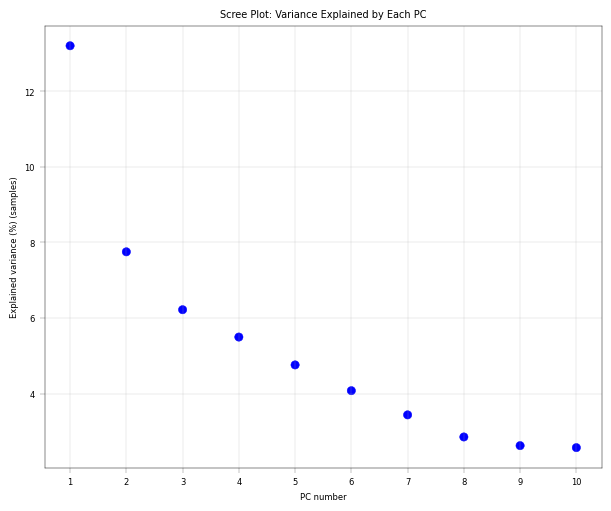

In [37]:
# Scree plot: variance explained by each PC
fig, axm = apt.pl.create_figure(1, 1, figsize=(6, 5))
ax = axm.next()

apt.pl.scree_plot(adata=adata, ax=ax, n_pcs=10)

apt.pl.label_axes(
    ax,
    title="Scree Plot: Variance Explained by Each PC",
)

# Increase axis ticks for better readability
ax.set_xticks(range(1, 11))

plt.show()

### Observation:

There is a pronounced "elbow" phenotype, and the first component far outweighs the remaining ones. after 4-5 components the variance explained is already close to zero.

### Conclusion:

The first component is worth investigating since it drives most of the core proteome variance. Also, after the fourth or fifth component there is no real gain in explained variance anymore, indicating that we don't need 10 components. As mentioned, it is important to note that this PCA is performed on only 30 core proteins. 

### 11.4.4 PCA Loadings: What Drives Each PC?

For components that capture a lot of variance, it can be very insightful to inspect their composition, i.e., which features (proteins) have the most influence on them. The **loadings** represent the contribution of each original feature to a principal component.
Mathematically, they are the coefficients that define the linear combination of original features forming each PC, and their magnitude indicates how strongly each feature influences that component.


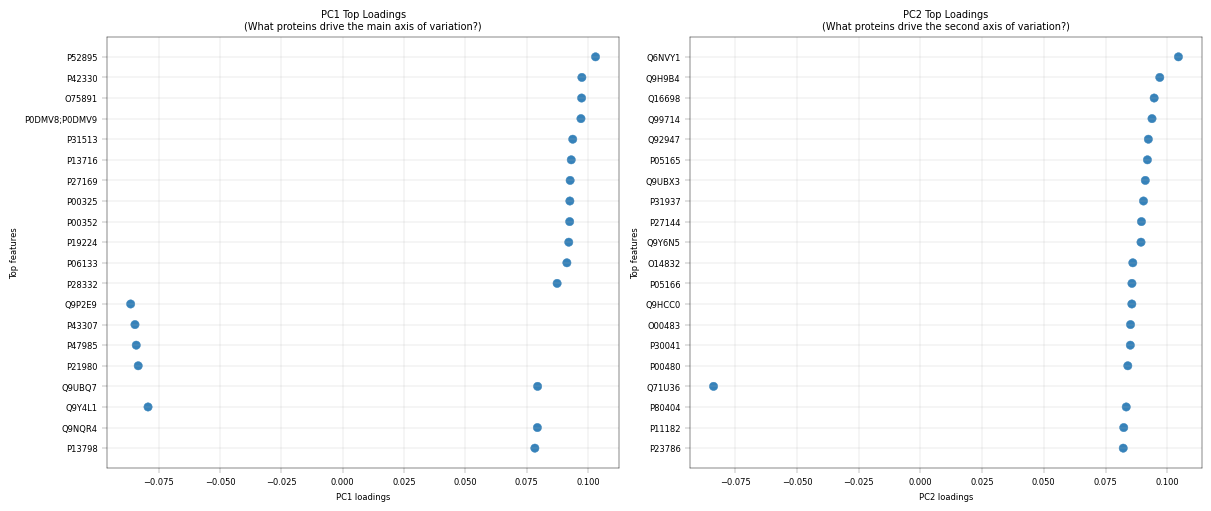

In [38]:
# Top loadings for PC1
fig, axm = apt.pl.create_figure(1, 2, figsize=(12, 5))

ax = axm.next()
apt.pl.plot_pca_loadings(
    data=adata,
    ax=ax,
    dim=1,
    nfeatures=20,
)
apt.pl.label_axes(
    ax,
    title="PC1 Top Loadings\n(What proteins drive the main axis of variation?)",
)

ax = axm.next()
apt.pl.plot_pca_loadings(
    data=adata,
    ax=ax,
    dim=2,
    nfeatures=20,
)
apt.pl.label_axes(
    ax,
    title="PC2 Top Loadings\n(What proteins drive the second axis of variation?)",
)

plt.show()

In [39]:
# Get the full feature metadata corresponding to the top loadings for PC1
top_pc1_loadings = apt.tl.prepare_pca_1d_loadings_data_to_plot(
    data=adata,
    dim_space="obs",
    dim=1,
    nfeatures=10,
)
top_pc1_loadings = top_pc1_loadings.merge(adata.var[["Genes"]], left_on="feature", right_index=True, how="left")
display(top_pc1_loadings.head(3))

top_pc2_loadings = apt.tl.prepare_pca_1d_loadings_data_to_plot(
    data=adata,
    dim_space="obs",
    dim=2,
    nfeatures=10,
)
top_pc2_loadings = top_pc2_loadings.merge(adata.var[["Genes"]], left_on="feature", right_index=True, how="left")
display(top_pc2_loadings.head(3))

,dim_loadings,feature,abs_loadings,index_int,Genes
0,0.103002,P52895,0.103002,10,AKR1C2
1,0.097439,P42330,0.097439,9,AKR1C3
2,0.097330,O75891,0.097330,8,ALDH1L1


,dim_loadings,feature,abs_loadings,index_int,Genes
0,0.104548,Q6NVY1,0.104548,10,HIBCH
1,0.096989,Q9H9B4,0.096989,9,SFXN1
2,0.094716,Q16698,0.094716,8,DECR1


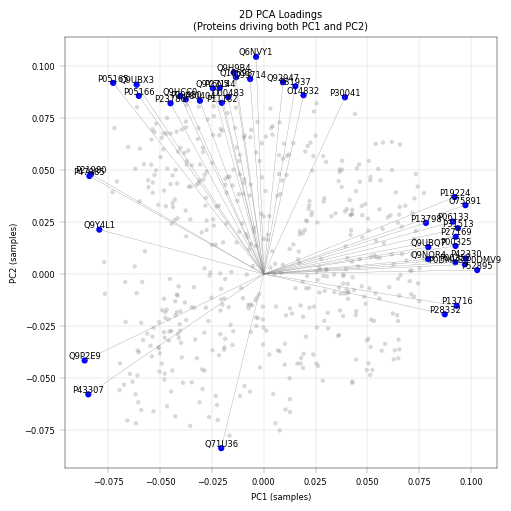

In [40]:
# 2D loadings plot

fig, axm = apt.pl.create_figure(1, 1, figsize=(5, 5))
ax = axm.next()

apt.pl.plot_pca_loadings_2d(
    data=adata,
    ax=ax,
    pc_x=1,
    pc_y=2,
    nfeatures=20,
    add_labels=True,
    add_lines=True,
)

apt.pl.label_axes(ax, title="2D PCA Loadings\n(Proteins driving both PC1 and PC2)")

plt.show()

### Observation:

**PC1 Top Loadings:**
- AKR1C2 (0.103), AKR1C3 (0.097), ALDH1L1 (0.097) - metablic pericentrally zonated proteins. 

**PC2 Top Loadings:**
- HIBCH (0.105), SFXN1 (0.097), DECR1 (0.095) - mitochondrial proteins

### Conclusions:

  This PCA is used primarily for quality control and exploratory validation rather than formal analysis. this analysis highlights several key points. Metabolic enzymes such as AKR1C2, AKR1C3, ALDH1L1 are among the top loadings in PC1, reflecting hepatocyte zonation (periportal vs. pericentral), consistent with known liver biology. The presence of mitochondrial proteins in PC2 may indicate variability mitochondial contenct of hepatocytes, which is also known to be periportally zonated.

---


## 12. Recreating Study Figures: Zonation Heatmap (Figure 2B)

### **Zonation Heatmap**

This visualization shows protein expression patterns across the portal-central axis, revealing which proteins are enriched in different liver zones.

### Construction Method
1. **Z-score normalization per donor**: Removes donor-specific baseline differences
2. **Bin samples by zonation score**: Group into discrete zones (the study used 20 bins from portal to central, we will use 5)
3. **Average Z-scores per bin**: Creates smooth gradient across zones
4. **Sort proteins by peak position**: Orders proteins by where they're most expressed

### Biological Interpretation

| Pattern | Meaning | Example Proteins |
|---------|---------|-----------------|
| High in bin 1 (central) | Pericentral-enriched | GLUL, CYP2E1, CYP1A2 |
| High in bin 5 (portal) | Periportal-enriched | CPS1, ASS1, PCK1 |
| Flat across bins | Non-zonated (housekeeping) | GAPDH, Actins |


> **Note** This part of the demo notebook departs somewhat from `alphapepttools`' core functionalities. This highlights one of our guiding design principles, namely to avoid closed "end to end" pipelines and allow full interface with open-source Python tools. As we see below, going from `AnnData` to `DataFrame` and applying custom Python code is a seamless transition.

In [41]:
from scipy.stats import zscore

# Convert adata.X to DataFrame (cells x proteins)
expr_df = pd.DataFrame(
    adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X, index=adata.obs_names, columns=adata.var_names
)

# List to collect per-donor binned means
binned_means_list = []

# Iterate over donors
for _donor, donor_cells in adata.obs.groupby("donor_id"):
    # Select expression for this donor
    donor_expr = expr_df.loc[donor_cells.index]
    # Calculate z-score per protein, ignoring NaNs
    donor_z = donor_expr.apply(lambda x: zscore(x, nan_policy="omit"), axis=0, result_type="broadcast")
    # Bin cells into 5 bins based on 'score'
    bins = pd.qcut(donor_cells["score"], q=5, labels=False) + 1  # bins 1-5
    donor_z["bin"] = bins
    # Calculate mean z-score per protein per bin, ignoring NaNs
    mean_per_bin = donor_z.groupby("bin").mean().T  # proteins as rows
    binned_means_list.append(mean_per_bin)

# Combine all donors: take mean across donors, ignoring NaNs
zone_z_means = pd.concat(binned_means_list, axis=0).groupby(level=0).mean()

  for _donor, donor_cells in adata.obs.groupby("donor_id"):



### Plotting the zonation heatmap:

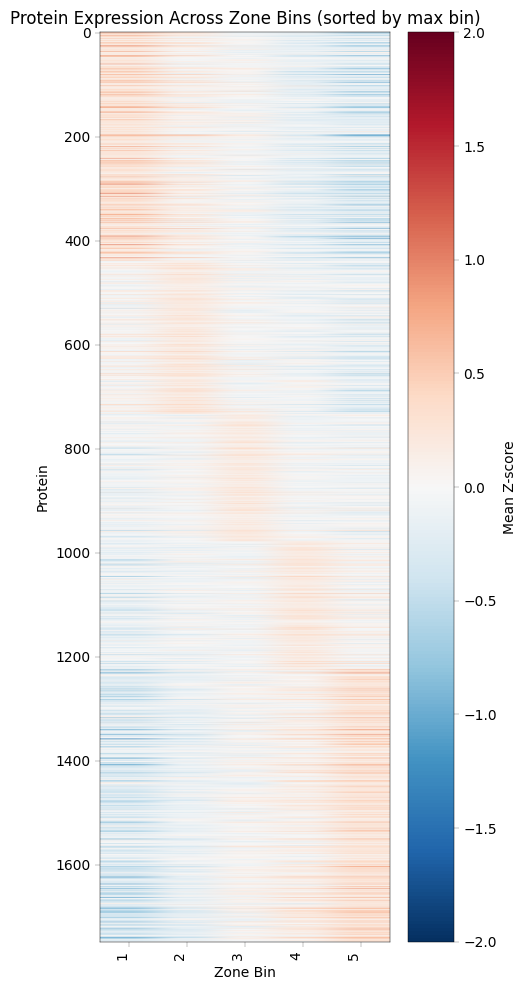

In [42]:
max_bin = zone_z_means.idxmax(axis=1)  # returns the column (bin) of max value per protein

# Sort proteins first by the bin of max value, then by max value descending
zone_z_means["max_bin"] = max_bin

# Sort by max_bin (ascending) and then max_value (descending)
zone_z_means_sorted = zone_z_means.sort_values(["max_bin"], ascending=True)

# Drop helper columns before plotting
zone_z_means_sorted = zone_z_means_sorted.drop(columns=["max_bin"])

# Plot heatmap
fig, ax = plt.subplots(figsize=(5, 10))
im = ax.imshow(zone_z_means_sorted.values, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)

ax.set_xlabel("Zone Bin")
ax.set_ylabel("Protein")
ax.set_xticks(range(len(zone_z_means_sorted.columns)))
ax.set_xticklabels(zone_z_means_sorted.columns, rotation=90, ha="right")

plt.colorbar(im, ax=ax, label="Mean Z-score")
plt.title("Protein Expression Across Zone Bins (sorted by max bin)")
plt.tight_layout()
plt.show()

---


## 13. Transcription Factor Activity Inference with Decoupler

### Why Infer TF Activity?

Proteomics measures **protein abundance**, but biological function is often controlled by **transcription factor (TF) activity**. 

**Key insight**: If a TF's target proteins are consistently upregulated, we can infer that TF is more active - even if we don't directly measure the TF itself.

### Decoupler Framework

We use **decoupler** to estimate TF activity from protein abundance:

1. **Prior Knowledge**: TF-target relationships from CollecTRI database
2. **Activity Score**: Statistical measure of target enrichment (ULM method)
3. **Comparison**: Identify TFs with differential activity across zones

### Important Caveats

- **Protein vs mRNA**: TF-target databases are often defined at mRNA level
- **Coverage**: Limited overlap between detected proteins and known TF targets
- **Post-translational regulation**: TF activity ≠ TF abundance (phosphorylation, localization matter)

Despite these limitations, TF activity inference provides biological insight beyond individual protein changes and can reveal regulatory mechanisms driving zonation patterns.

Import decoupler package:

In [43]:
# decoupler imports
import decoupler as dc

  from .autonotebook import tqdm as notebook_tqdm



### **13.1 Data preparation**

- log transform (while making sure we're working on the right layer), where we choose the `log1p` function from `scanpy`, as ULM doesn't accept nan values.

In [44]:
adata_dc = adata.copy()

# we will revert back to the 0-filled data for this analysis (directLFQ output), as decoupler's implementation does not handle missing values
adata_dc.X = adata_dc.layers["orig_intensity"].copy()
zero_mask = apt.pp.detect_special_values(adata_dc.X)
adata_dc.X = np.where(zero_mask, 0, adata_dc.X)

# normalize the data with log1p transformation (log2(x+1)) to reduce the impact of extreme values and make the data more suitable for downstream analysis
sc.pp.log1p(adata_dc, base=2)

- Loading the TF-target dataset from the package and check intersection:

In [45]:
# Get CollecTRI TF-target network
collectri = dc.op.collectri(organism="human")

print(f"CollecTRI network: {len(collectri)} TF-target interactions")
print(f"Number of TFs: {collectri['source'].nunique()}")
print(f"Number of target genes: {collectri['target'].nunique()}")
print("\nNetwork structure:")
display(collectri.head(10))

# Check overlap between our proteins and the TF-target network
our_genes = set(adata_dc.var["single_gene_name"])
network_targets = set(collectri["target"])
overlap = our_genes.intersection(network_targets)

print(f"Genes in our data: {len(our_genes)}")
print(f"Target genes in network: {len(network_targets)}")
print(f"Overlap: {len(overlap)} ({100 * len(overlap) / len(our_genes):.1f}%)")

print(f"number of overlapping proteins is {len(overlap)}, make sure it is sufficient for robust TF activity inference.")


# make unique row indices
adata_dc.var_names = adata_dc.var["single_gene_name"]
print(adata_dc.var_names)

adata_dc.var_names_make_unique()
adata_dc.shape

CollecTRI network: 42990 TF-target interactions
Number of TFs: 1185
Number of target genes: 6675

Network structure:


,source,target,weight,resources,references,sign_decision
0,MYC,TERT,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,SPI1,BGLAP,1.0,ExTRI,10022617,default activation
2,SMAD3,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
3,SMAD4,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
4,STAT5A,IL2,1.0,ExTRI,10022878;11435608;17182565;17911616;22854263;2...,default activation
5,STAT5B,IL2,1.0,ExTRI,10022878,regulon
6,RELA,FAS,1.0,ExTRI;NTNU.Curated;TRRUST,10022897;10871852;11290773;11473033;16317104;1...,PMID
7,WT1,NR0B1,1.0,ExTRI;GEREDB,10022915;12151099,PMID
8,NR0B2,CASP1,1.0,ExTRI,10022928,default activation
9,SP1,ALDOA,1.0,DoRothEA-A;ExTRI;TFactS,10023068;8524331,PMID


Genes in our data: 1749
Target genes in network: 6675
Overlap: 878 (50.2%)
number of overlapping proteins is 878, make sure it is sufficient for robust TF activity inference.
Index(['GATD3', 'TRBJ1-3', 'UBA6', 'SHTN1', 'ILVBL', 'ANKRD18B', 'FUOM',
       'VWA8', 'USP17L1', 'ASPDH',
       ...
       'ALG5', 'COPG1', 'CLIC4', 'NFS1', 'SPCS1', 'EMILIN1', 'MTCH2',
       'SLCO1B1', 'SQOR', 'SEC23IP'],
      dtype='object', name='single_gene_name', length=1749)


(386, 1749)

### **13.2 Running TF Activity Inference**

Decoupler provides multiple methods for activity inference. We'll use `run_ulm` (Univariate Linear Model) as the primary method, which performs a linear regression for each TF.

In [46]:
# Run Univariate Linear Model (ULM) for TF activity inference
dc.mt.ulm(
    data=adata_dc,
    net=collectri,
    verbose=True,
    raw=False,
)

# Results are stored in adata.obsm
print("\nResults stored in:")
print("  - adata_dc.obsm['ulm_estimate']: TF activity scores")
print("  - adata_dc.obsm['ulm_pvals']: p-values")

2026-07-24 18:54:15 | [INFO] ulm - Running ulm
INFO:decoupler:ulm - Running ulm
2026-07-24 18:54:15 | [INFO] Extracted omics mat with 386 rows (observations) and 1749 columns (features)
INFO:decoupler:Extracted omics mat with 386 rows (observations) and 1749 columns (features)
2026-07-24 18:54:15 | [INFO] Network adjacency matrix has 837 unique features and 219 unique sources
INFO:decoupler:Network adjacency matrix has 837 unique features and 219 unique sources
2026-07-24 18:54:15 | [INFO] ulm - fitting 219 univariate models of 1749 observations (targets) with 1747 degrees of freedom
INFO:decoupler:ulm - fitting 219 univariate models of 1749 observations (targets) with 1747 degrees of freedom
2026-07-24 18:54:15 | [INFO] ulm - adjusting p-values by FDR
INFO:decoupler:ulm - adjusting p-values by FDR
2026-07-24 18:54:15 | [INFO] ulm - done
INFO:decoupler:ulm - done



Results stored in:
  - adata_dc.obsm['ulm_estimate']: TF activity scores
  - adata_dc.obsm['ulm_pvals']: p-values


### **13.3 Extracting TF activity**

Whereby we estimate and show the top 20 active TFs in the hepatocytes and the top 20 variable TFs:

In [47]:
tf_activities = adata_dc.obsm["score_ulm"]
tf_pvals = adata_dc.obsm["padj_ulm"]

# calculate tf_activities column means
tf_activities_means = tf_activities.mean()
# sort by means
tf_activities_means = tf_activities_means.sort_values(ascending=False)
print("\nTop TFs by mean activity:")
print(tf_activities_means.head(20))

# variance of tf_activities
tf_var = tf_activities.var().sort_values(ascending=False)
print("\nTop TFs by activity variance:")
print(tf_var.head(20))


Top TFs by mean activity:
CEBPB     5.219989
CEBPG     4.122904
PPARA     3.777427
SP1       3.627627
CEBPA     3.602471
DBP       3.286541
PPARG     3.138030
KLF11     3.060686
RARB      2.948902
HNF4A     2.920039
AR        2.842844
TBP       2.792359
HIF1A     2.776538
HNF1A     2.764622
JUN       2.754386
DDIT3     2.753949
ESR1      2.691661
SREBF1    2.633109
TP53      2.625670
MYC       2.614391
dtype: float64

Top TFs by activity variance:
SRSF2     2.317597
SMAD3     1.674247
CEBPE     1.608267
SOX9      1.422943
MBD2      1.414417
CREM      1.261852
MAF       1.217511
CEBPB     1.147923
SP1       1.138412
NR1I3     1.115499
KAT7      1.056508
CUX1      1.049809
HNF4G     1.034934
EP300     1.032372
MYC       1.010706
SMAD7     0.990555
NKX2-5    0.976983
REL       0.952067
STAT1     0.950039
TP53      0.936359
dtype: float64


### **13.4 Compare TF Activities Between Cetral and Portal zones**


In [48]:
# Add condition to activities dataframe
tf_activities_df = tf_activities.copy()
tf_activities_df["zone"] = adata_dc.obs["zone"].to_numpy()

# Calculate mean activity per condition
mean_by_condition = tf_activities_df.groupby("zone").mean()

# Calculate activity difference (AD - Control)
activity_diff = mean_by_condition.loc["zone_1"] - mean_by_condition.loc["zone_5"]
activity_diff = activity_diff.sort_values()

print("TFs more active in zone 1 - central (top 10):")
print(activity_diff.tail(10))
print("\nTFs less active in zone 5 - portal (top 10):")
print(activity_diff.head(10))

TFs more active in zone 1 - central (top 10):
NCOA2    0.898053
NR2F1    0.910050
NR1I2    0.915232
USF1     0.981712
DBP      0.990746
NR1H3    1.013172
ARNT     1.109525
HNF1A    1.144379
AHR      1.151812
NR1I3    1.660021
dtype: float64

TFs less active in zone 5 - portal (top 10):
MAF     -1.491296
NCOR2   -0.930682
FOXO1   -0.875879
DNMT1   -0.788788
RELA    -0.728302
SMAD7   -0.580310
NR4A1   -0.555089
ETS2    -0.449779
STAT3   -0.448857
KLF6    -0.399281
dtype: float64


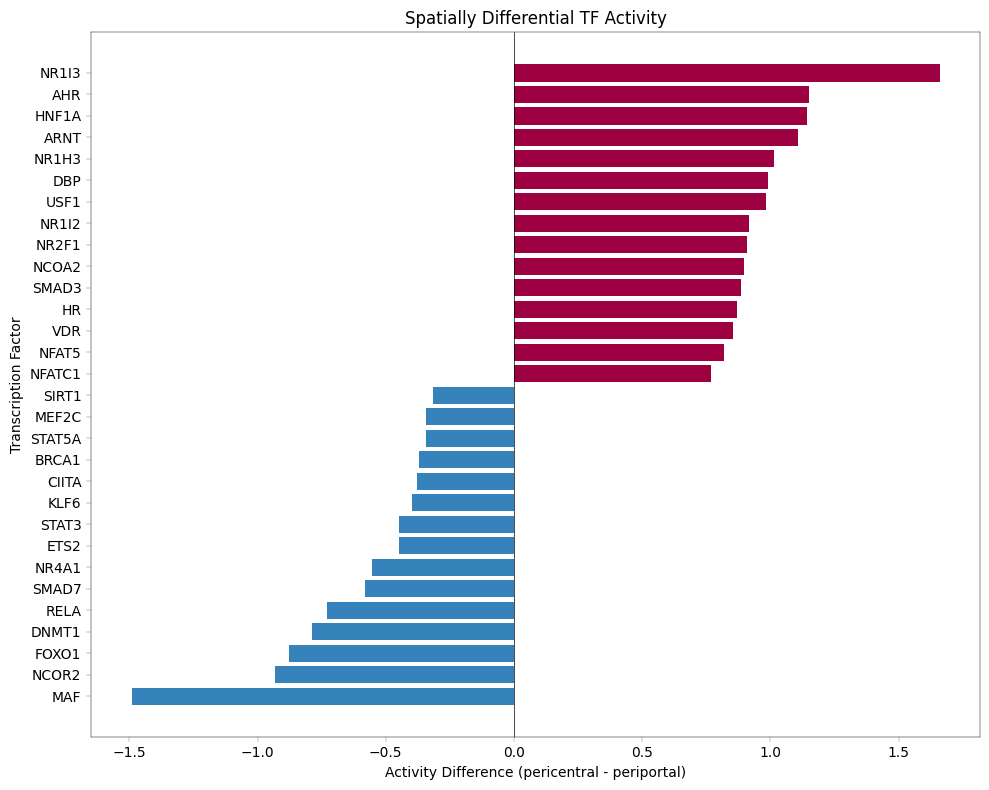

In [49]:
# Plot top differential TFs
n_top = 15
top_up = activity_diff.tail(n_top)
top_down = activity_diff.head(n_top)
top_diff = pd.concat([top_down, top_up])

fig, ax = plt.subplots(figsize=(10, 8))
colors = [apt.pl.BaseColors.get("blue") if x < 0 else apt.pl.BaseColors.get("red") for x in top_diff.to_numpy()]
ax.barh(range(len(top_diff)), top_diff.to_numpy(), color=colors)
ax.set_yticks(range(len(top_diff)))
ax.set_yticklabels(top_diff.index)
ax.axvline(x=0, color="black", linewidth=0.5)
ax.set_xlabel("Activity Difference (pericentral - periportal)")
ax.set_ylabel("Transcription Factor")
ax.set_title("Spatially Differential TF Activity")

plt.tight_layout()
plt.show()

### Observation
The identified highest differential TF NR1I3 was indeed found to induce pericentral functions in the liver (https://www.sciencedirect.com/science/article/pii/S1534580725006653?via%3Dihub). Inversely, the lowest differential TF MAF was found to be associated with silencing the pericentral functions, where MAF deletion resulted in larger pericentral areas (hepatocytes remoted from CV also exressed GS, otherwise exclussively expressed by pericentral hepatocytes: https://www.sciencedirect.com/science/article/pii/S1934590922001096). 

### Conclusion
This anecdotal validation using literature concordance serves as a technical validation rather than biological inference, confirming that our approach recovers expected zonation-associated TFs.


### **13.5 Violin Plots for Specific TFs**

Examining the distribution of activity scores for specific TFs of interest.

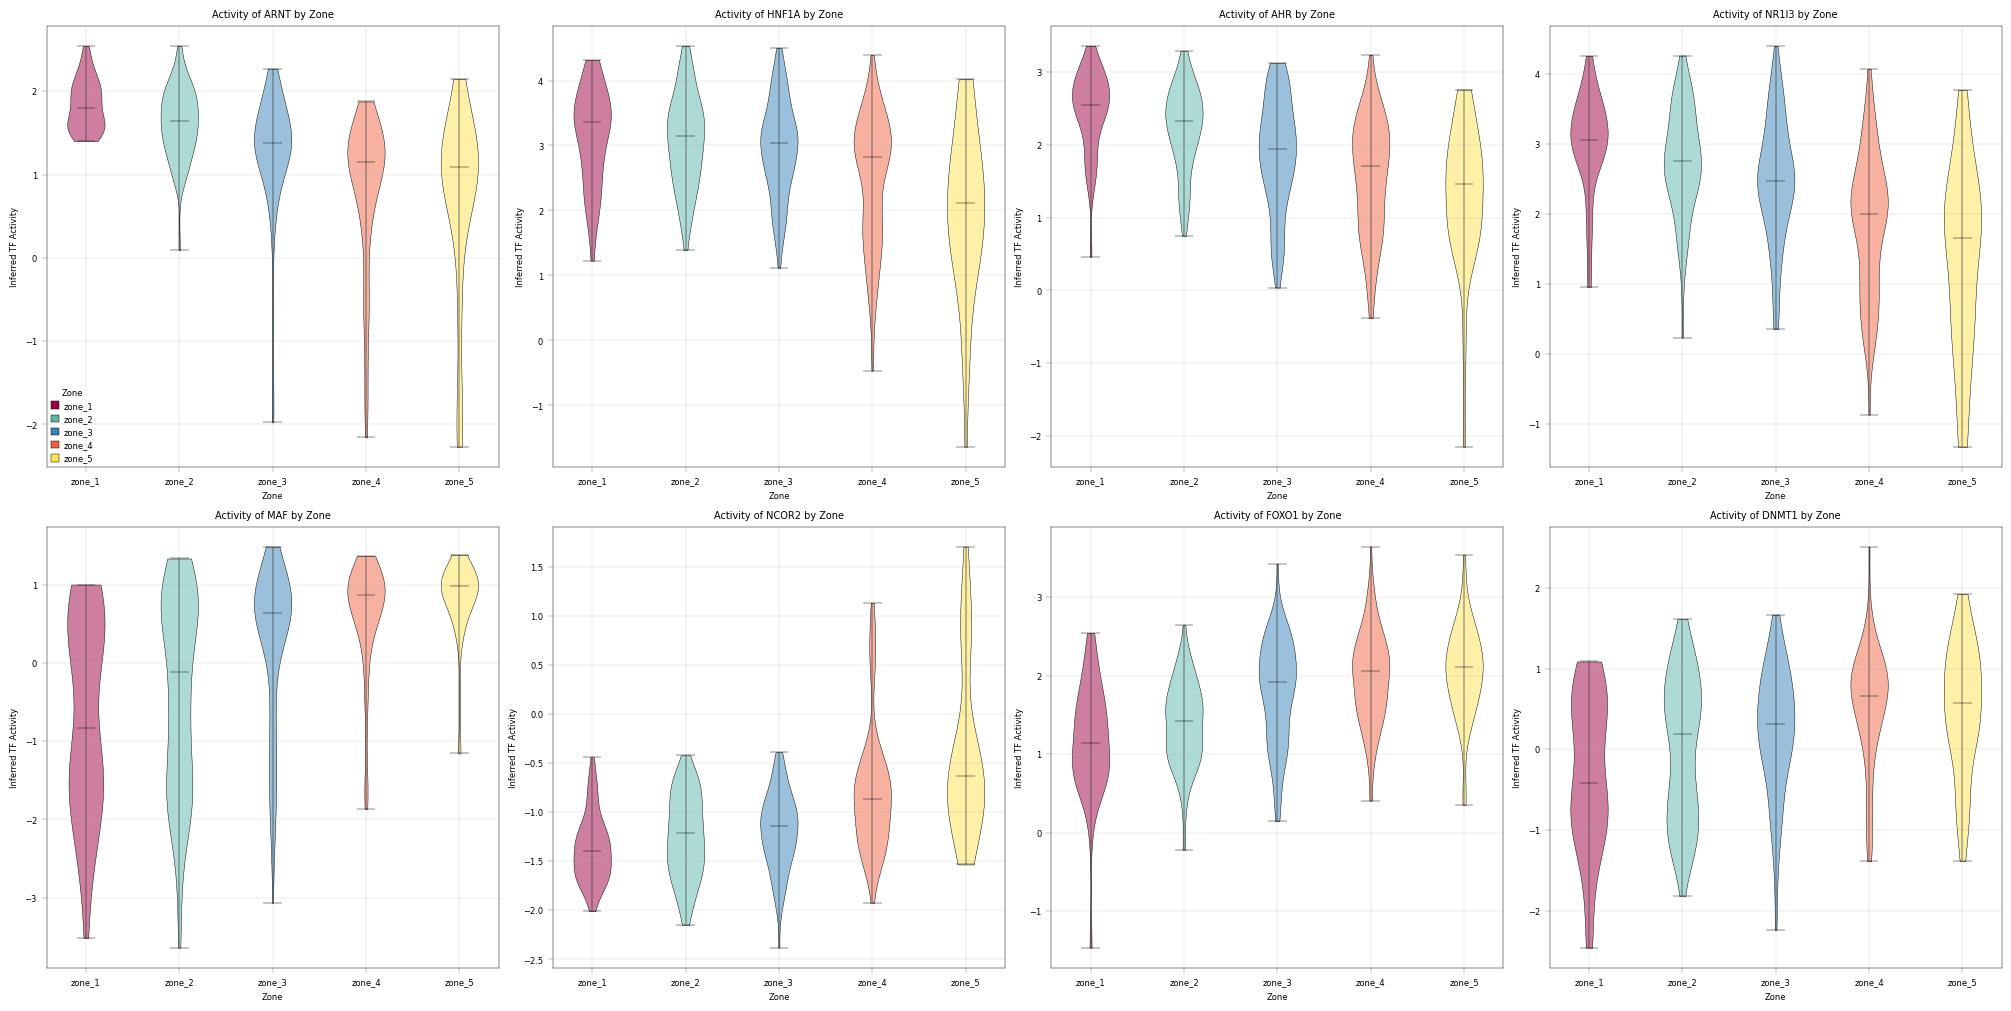

In [50]:
# Select TFs to visualize
tfs_to_plot = top_diff.tail(4).index.tolist() + top_diff.head(4).index.tolist()
tfs_to_plot = [tf for tf in tfs_to_plot if tf in tf_activities.columns]

if len(tfs_to_plot) > 0:
    # Create AnnData with TF activities for easy plotting with scanpy
    adata_tf = ad.AnnData(
        X=tf_activities.values, obs=adata_dc.obs.copy(), var=pd.DataFrame(index=tf_activities.columns)
    )

    # Plot violin plots
    fig, axm = apt.pl.create_figure(2, 4, figsize=(20, 10))

    for i, tf in enumerate(tfs_to_plot[:8]):
        if tf in adata_tf.var_names:
            ax = axm[i]

            apt.pl.violinplot(
                ax=ax,
                data=adata_tf,
                grouping_column="zone",
                value_column=tf,
                color_dict=biological_color_dict,
            )

            apt.pl.label_axes(
                ax,
                title=f"Activity of {tf} by Zone",
                xlabel="Zone",
                ylabel="Inferred TF Activity",
            )

            # Add a legend to the first plot for clarity
            if i == 0:
                apt.pl.add_legend_to_axes(
                    ax,
                    levels=biological_color_dict,
                    title="Zone",
                )

    plt.show()

---


## 14. Overlay of proteomics data with spatial information

The single-cell proteomics measurements analyzed above were acquired by single-cell Deep Visual Proteomics (scDVP), where individual cells are excised from a stained tissue section by laser microdissection. Because every cell retains its original spatial coordinates, we can map the measured proteome back onto the tissue image and inspect protein abundance *in situ*.

We use the [`spatialdata`](https://spatialdata.scverse.org/) framework to combine three layers of information into a single object: the microscopy **image**, the cell **shapes** (segmentation polygons stored as a `GeoDataFrame`), and the proteomics **table** (our `AnnData`).

> **Note:** `spatialdata` is not a dependency of `alphapepttools` and must be installed separately, e.g. via `pip install "spatialdata[all]"`. This also provides the `spatialdata-plot` and `spatialdata-io` helpers used below.

In [51]:
# pip install "spatialdata[all]"

In [52]:
import geopandas as gpd
import spatialdata as sd
import spatialdata_plot  # noqa: F401
from spatialdata_io import generic as sdio
from matplotlib.colors import Normalize

We download the image data and cell coordinates for a single healthy patient (NML10)

In [53]:
image_path = apt.data.get_data("Weiss2026_image")
shapes_path = apt.data.get_data("Weiss2026_shapes")

/Users/vincenthbrennsteiner/Documents/mann_labs/_git_repositories/alphapepttools-manuscript/notebooks/studies/NML10_crop.png already exists (2.405837059020996 MB)
/Users/vincenthbrennsteiner/Documents/mann_labs/_git_repositories/alphapepttools-manuscript/notebooks/studies/NML10.geojson already exists (0.10878562927246094 MB)


And use the generic spatialdata-io functions to ingest the image and shape data into the scverse ecosystem. For more information about the spatialdata framework, have a look at the [documentation](https://spatialdata.scverse.org/en/stable/index.html) there. Note that for more complex imaging + shape data as they can occur for DVP data, you can use the dedicated reader package [`dvp-io`](https://dvp-io.readthedocs.io/en/latest/index.html).

In [54]:
# Read shapes as geopandas dataframe to retain indexing
shapes_gdf = gpd.read_file(shapes_path).set_index("idx")

# Read data and construct a spatialdata object.
sdata = sd.SpatialData(
    images={"image": sdio(image_path, data_axes=("x", "y", "c"), coordinate_system="global")},
    shapes={
        "cells": sd.models.ShapesModel.parse(shapes_gdf, transformations={"global": sd.transformations.Identity()})
    },
)

In [55]:
sdata["cells"]

,geometry
idx,
1,"POLYGON ((1085.60413 852.79899, 1084.60413 853..."
2,"POLYGON ((1101.60413 943.79899, 1100.60413 944..."
3,"POLYGON ((1046.60411 1008.79899, 1045.60411 10..."
4,"POLYGON ((956.60409 1112.79899, 955.60409 1113..."
5,"POLYGON ((848.60405 1104.79899, 845.60405 1107..."
6,"POLYGON ((763.60403 1100.79899, 762.60403 1101..."
7,"POLYGON ((725.60402 945.79899, 724.60402 946.7..."
8,"POLYGON ((595.60398 942.79899, 594.60398 943.7..."
9,"POLYGON ((459.80394 896.79899, 457.80394 898.7..."


The resulting spatialdata object contains the image under the key `image` and the cell coordinates under the key `cells`.

### **14.1 Linking the proteomics table to the cell shapes**

`spatialdata` keeps images, shapes, and tables as separate elements and connects them through an **explicit annotation**. We therefore have to tell `spatialdata` how each row of the proteomics table relates to a cell shape:

- `region="cells"` together with `region_key="region"` declares which shapes element the table annotates.
- `instance_key="geometry_id"` names the column in `table.obs` whose values must match the **index of the shapes `GeoDataFrame`**. This index-to-table correspondence is what lets `spatialdata` resolve which polygon each measured cell belongs to.

For a detailed explanation of how tables annotate shapes and how to query across elements, see the [spatial query tutorial](https://spatialdata.scverse.org/en/stable/tutorials/notebooks/notebooks/examples/spatial_query.html).

In [56]:
table = adata.copy()

# Subset to the specific donor for which we obtained the image + shapes
table = table[table.obs["donor_id"] == "NML10"]
table.obs["pc1"] = table.obsm["X_pca_obs"][:, 0].tolist()

# Add a column in the .obs attribute that tells spatialdata, which element the table annotates (=cells)
table.obs["region"] = "cells"

# Add the anndata object to the spatialdata object.
sdata.tables["proteomics"] = sd.models.TableModel.parse(table, region="cells", region_key="region", instance_key="geometry_id")

matched_elements, matched_table = sd.join_spatialelement_table(
    sdata, spatial_element_names="cells", table_name="proteomics", how="inner"
)
print(f"Found {matched_table.n_obs} shared observations")

  table.obs["pc1"] = table.obsm["X_pca_obs"][:, 0].tolist()

  convert_region_column_to_categorical(adata)



Found 35 shared observations


In [57]:
table.obs

,id,score,donor_id,plate_id,condition,geometry_id,zone,total_sample_intensity,num_features_detected,fraction_detected_features,log10_sum_intensity,sample_absolute_deviation,num_proteins_MAD,is_outlier,donor_zone_condition,pcv,z_outlier,pc1,region
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX06_NML10_shape_02,696.0,0.191385,NML10,plate_3,control,2,zone_1,2.142241e+08,2224,0.429758,8.330868,130.0,-0.204403,False,NML10_zone_1_control,0.323265,False,-1.988403,cells
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX06_NML10_shape_03,705.0,0.175330,NML10,plate_3,control,3,zone_1,2.272042e+08,2917,0.563671,8.356416,563.0,0.885220,False,NML10_zone_1_control,0.323265,False,2.216017,cells
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX06_NML10_shape_04,709.0,0.185412,NML10,plate_3,control,4,zone_1,2.284482e+08,3027,0.584928,8.358788,673.0,1.058176,False,NML10_zone_1_control,0.323265,False,4.270352,cells
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX06_NML10_shape_11,797.0,0.174534,NML10,plate_3,control,11,zone_1,2.375595e+08,2792,0.539517,8.375772,438.0,0.688679,False,NML10_zone_1_control,0.323265,False,1.730161,cells
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX06_NML10_shape_38,1475.0,0.379582,NML10,plate_3,control,38,zone_2,2.110220e+08,1676,0.323865,8.324328,678.0,-1.066038,False,NML10_zone_2_control,0.404063,False,-0.600383,cells
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX06_NML10_shape_35,1462.0,0.376983,NML10,plate_3,control,35,zone_2,2.161667e+08,3181,0.614686,8.334789,827.0,1.300314,False,NML10_zone_2_control,0.404063,False,-1.108602,cells
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX06_NML10_shape_40,1489.0,0.299180,NML10,plate_3,control,40,zone_2,2.321050e+08,2671,0.516135,8.365684,317.0,0.498428,False,NML10_zone_2_control,0.404063,False,-1.151671,cells
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX06_NML10_shape_41,1490.0,0.365894,NML10,plate_3,control,41,zone_2,2.248910e+08,2530,0.488889,8.351972,176.0,0.276730,False,NML10_zone_2_control,0.404063,False,-2.655204,cells
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX06_NML10_shape_43,12240.0,0.213304,NML10,plate_3,control,43,zone_2,2.300750e+08,2250,0.434783,8.361869,104.0,-0.163522,False,NML10_zone_2_control,0.404063,False,-4.039217,cells
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX06_NML10_shape_42,1494.0,0.370580,NML10,plate_3,control,42,zone_2,2.232170e+08,1895,0.366184,8.348727,459.0,-0.721698,False,NML10_zone_2_control,0.404063,False,-0.089444,cells


In [58]:
matched_elements, matched_table = sd.join_spatialelement_table(
    sdata, spatial_element_names="cells", table_name="proteomics", how="inner"
)
print(f"Found {matched_table.n_obs} shared observations")

Found 35 shared observations


In [59]:
table

AnnData object with n_obs × n_vars = 35 × 1749
    obs: 'id', 'score', 'donor_id', 'plate_id', 'condition', 'geometry_id', 'zone', 'total_sample_intensity', 'num_features_detected', 'fraction_detected_features', 'log10_sum_intensity', 'sample_absolute_deviation', 'num_proteins_MAD', 'is_outlier', 'donor_zone_condition', 'pcv', 'z_outlier', 'pc1', 'region'
    var: 'Protein.Group', 'Protein.Names', 'Genes', 'total_feature_intensity', 'num_samples_detected', 'fraction_detected_samples', 'protein_rank', 'median_intensity', 'pass_completeness_filter', 'CV', 'CV_imp', 'protein_mean_imp', 'single_gene_name', 'is_keratin', 'is_core', 'prot_for_pca'
    uns: 'variance_pca_obs', 'spatialdata_attrs'
    obsm: 'X_pca_obs'
    varm: 'PCs_pca_obs'
    layers: 'orig_intensity', 'min_imputed'

### **14.2 Overlaying protein abundance on the tissue**

Finally, we render the tissue image and color each cell shape by a protein of interest. Here we plot **CYP1A2** (UniProt `P05177`), the same pericentral (central zone) marker we examined in the PCA overlay above. CYP1A2 follows the portal-to-central zonation axis, so we expect higher (scaled) abundance toward the central veins and lower abundance toward the portal regions, directly recapitulating the liver zonation pattern on the tissue section.

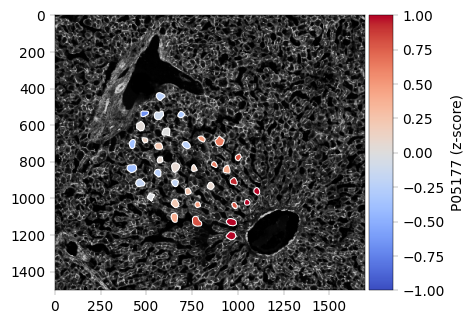

In [60]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
(
    sdata.pl.render_images("image", palette="#444444")
    .pl.render_shapes(
        "cells",
        color="P05177",
        norm=Normalize(-1, 1, clip=True),
        cmap="coolwarm",
        outline_color="#ffffff",
        outline_alpha=1,
    )
    .pl.show(title="", ax=ax, colorbar_params={"label": "P05177 (z-score)"})
)


## generate the plots for the manuscript:

In [61]:
from alphapepttools.pl.defaults import plot_settings
from matplotlib import colors as mpl_colors

plot_settings.preset_sizes
p2i = 25.4

  return dispatch(args[0].__class__)(*args, **kw)



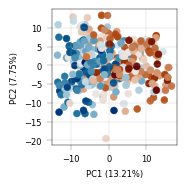

In [64]:
# Plot 1: PCA colored by zonation score

# Make the distance value agree with the general directionality (left = portal, right = central), so we multiply by -1
adata.obs["score_from_PN"] = 1 - adata.obs["score"]

# Colormap: to ensure the colorbar and scatter agree, both use the same fixed bounds.
# Snap to the neighbouring integers (0 and 1) so the colors span the full colormap.
lo = np.floor(adata.obs["score_from_PN"].min())
hi = np.ceil(adata.obs["score_from_PN"].max())

# Fit the mapper to the fixed bounds, then map the scores to colors on that same scale
mapper = MappedColormaps(cmap="cmc.vik").fit(vmin=lo, vmax=hi)
adata.obs["score_from_PN_mapped"] = mapper.transform(adata.obs["score_from_PN"].to_numpy(), as_hex=True)

fig, axm = apt.pl.create_figure(1, 1, figsize=("0.5", "0.5"))
ax = axm.next()

apt.pl.plot_pca(
    data=adata,
    ax=ax,
    x_column=1,
    y_column=2,
    label=False,
    color_column="score_from_PN_mapped",
    scatter_kwargs={"s": 25},
)

ax.set_aspect('equal')

# apt.pl.label_axes(
#     ax=ax, 
#     title="PCA colored by hepatocye porto-central spatial location",
# )

apt.pl.save_figure(
    fig = fig,
    filename = "pca_zonation.png",
    output_dir = figure_output_dir,
    dpi=600,
    transparent=True
)

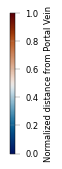

In [69]:
# Separate axis for color bar
fig, axm = apt.pl.create_figure(1, 1, figsize=(13 / p2i, 40 / p2i))
# fig, axm = apt.pl.create_figure(1, 1, figsize=(4 / p2i, 40 / p2i), subplots_kwargs={"constrained_layout": False})

ax=axm.next()

cbar_params = {
    "orientation": "vertical", 
} 

_ = fig.colorbar(
    cax = ax,
    mappable=mapper.scalar_mappable, 
    **cbar_params
    )

# ensure that we have 0.2 incremented axis labels between and including 0 and 1
ax.set_yticks(np.arange(0, 1.01, 0.2))

apt.pl.label_axes(
    ax=ax, 
    ylabel="Normalized distance from Portal Vein",
)

apt.pl.save_figure(
    fig = fig,
    filename = "pca_zonation_colorbar.png",
    output_dir = figure_output_dir,
    dpi=600,
    transparent=True
)


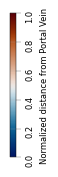

In [83]:
# Separate axis for color bar
fig, axm = apt.pl.create_figure(1, 1, figsize=(12 / p2i, 42 / p2i))
# fig, axm = apt.pl.create_figure(1, 1, figsize=(4 / p2i, 40 / p2i), subplots_kwargs={"constrained_layout": False})

ax=axm.next()

cbar_params = {
    "orientation": "vertical", 
} 

_ = fig.colorbar(
    cax = ax,
    mappable=mapper.scalar_mappable, 
    **cbar_params
    )

# ensure that we have 0.2 incremented axis labels between and including 0 and 1
ax.set_yticks(np.arange(0, 1.01, 0.2))
# rotate y ticks by 90 degrees for better readability
ax.set_yticklabels([f"{x:.1f}" for x in np.arange(0, 1.01, 0.2)], rotation=90)

apt.pl.label_axes(
    ax=ax, 
    ylabel="Normalized distance from Portal Vein",
)

apt.pl.save_figure(
    fig = fig,
    filename = "pca_zonation_colorbar.png",
    output_dir = figure_output_dir,
    dpi=600,
    transparent=True
)


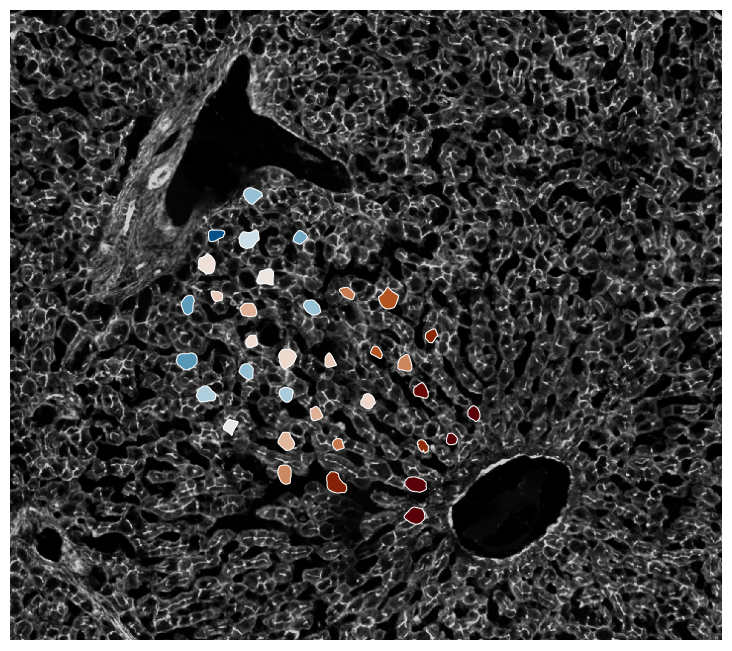

In [76]:
# Plot 2: Spatial protein overlay 

# Generate color mapper with the standardized min and max values
norm = Normalize(-1, 1, clip=True)
scalar_mappable = cm.ScalarMappable(cmap=cmc.vik, norm=norm)

# render_shapes applies the normalization along with color mapping by default
# Save this bigger than it should be to avoid blurry images in Illustrator - a rare exception to the "never resize" rule :D
fig, axm = apt.pl.create_figure(1, 1, figsize=("2", "2"))
ax = axm.next()
(
    sdata.pl.render_images("image", palette="#444444")
    .pl.render_shapes(
        "cells",
        color="P05177",
        norm=norm,
        cmap=cmc.vik,
        outline_color="#ffffff",
        outline_alpha=1,
    )
    .pl.show(
        title="",
        ax=ax,
        colorbar=False,
    )
)
ax.axis("off")
ax.set_aspect('equal')

apt.pl.save_figure(
    fig = fig,
    filename = "spatial_overlay_P05177.png",
    output_dir = figure_output_dir,
    dpi=600,
    transparent=True
)

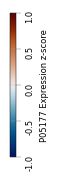

In [81]:
# Separate axis for color bar
# fig, axm = apt.pl.create_figure(1, 1, figsize=(14.75 / p2i, 40 / p2i))
fig, axm = apt.pl.create_figure(1, 1, figsize=(12 / p2i, 43 / p2i))

ax=axm.next()

cbar_params = {
    "orientation": "vertical", 
} 

_ = fig.colorbar(
    cax = ax,
    mappable=scalar_mappable, 
    **cbar_params
    )

ax.set_yticks(np.arange(-1, 1.01, 0.5))
# rotate y ticks by 90 degrees for better readability
ax.set_yticklabels([f"{x:.1f}" for x in np.arange(-1, 1.01, 0.5)], rotation=90)

apt.pl.label_axes(
    ax=ax, 
    ylabel="P05177 Expression z-score",
)

apt.pl.save_figure(
    fig = fig,
    filename = "spatial_overlay_P05177_colorbar.png",
    output_dir = figure_output_dir,
    dpi=600,
    transparent=True
)

## 15. Summary & Key Takeaways

### What We Accomplished

1. **Data Loading**: Imported scDVP proteomics data into AnnData format with alphapepttools
2. **Quality Control**: Assessed sample and protein quality, identified technical vs biological variation
3. **Filtering**: Applied manuscript-based thresholds for samples and proteins
4. **PCA Analysis**: Explored variance structure, confirmed biological signal
5. **Zonation Heatmap**: Recreated Figure 2B showing protein gradients across liver zones
6. **TF Activity**: Inferred transcription factor activity differences between zones
7. **Visualizaton**: Overlaying the data with the available spatial information.

### Key Proteomics Insights

### Things to Watch Out For
- **Missing values are NOT random**: Low-abundance proteins have more missingness
- **Contaminants dominate**: Consider excluding from some analyses
- **Batch effects**: Always check if technical factors drive variance

### Next Steps
- Apply batch correction if needed (ComBat)
- If needed, consider imputation and/or additional normalization, and assess the QC metrics again to see if there is an improvement


